# Visualisation Results

This notebook will analyse the results coming from the GARG-AML scores, AutoAudit and Flowscope. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
models = [
    'flowscope', 
    'autoaudit', 
    'gargaml_u',
    'gargaml_d', 
    'gargaml_tree_u',
    'gargaml_boost_u', 
    'gargaml_tree_d',
    'gargaml_boost_d'
]

patterns = [
    'laundering', 
    'separate',
    'new_mules', 
    'existing_mules'
]

In [3]:
datasets = []

n_nodes_list = [100, 10000, 100000] # Number of nodes in the graph
m_edges_list = [1, 2, 5] # Number of edges to attach from a new node to existing nodes
p_edges_list = [0.001, 0.01] # Probability of adding an edge between two nodes
generation_method_list = [
    'Barabasi-Albert', 
    'Erdos-Renyi', 
    'Watts-Strogatz'
    ] # Generation method for the graph
n_patterns_list = [3, 5] # Number of smurfing patterns to add

for n_nodes in n_nodes_list:
        for n_patterns in n_patterns_list:
            if n_patterns <= 0.06*n_nodes:
                for generation_method in generation_method_list:
                    if generation_method == 'Barabasi-Albert':
                        p_edges = 0
                        for m_edges in m_edges_list:
                            string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                            datasets.append(string_name)
                    if generation_method == 'Erdos-Renyi':
                        m_edges = 0
                        for p_edges in p_edges_list:
                            string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                            datasets.append(string_name)
                    if generation_method == 'Watts-Strogatz':
                        for m_edges in m_edges_list:
                            for p_edges in p_edges_list:
                                string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                                datasets.append(string_name)

In [4]:
file = '../results-aa/synthetic_autoaudit_combined.csv'
df = pd.read_csv(file)
df = df.rename(columns={'Unnamed: 0': 'pattern'})
df.head()

,pattern,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_5,synthetic_Barabasi-Albert_100000_5_0_5,synthetic_Erdos-Renyi_100000_0_0.001_5,synthetic_Erdos-Renyi_100000_0_0.01_5,synthetic_Watts-Strogatz_100000_1_0.001_5,synthetic_Watts-Strogatz_100000_1_0.01_5,synthetic_Watts-Strogatz_100000_2_0.001_5,synthetic_Watts-Strogatz_100000_2_0.01_5,synthetic_Watts-Strogatz_100000_5_0.001_5,synthetic_Watts-Strogatz_100000_5_0.01_5
0,laundering,"(0.5626432391138273, 0.5972903284976617)","(0.7511851081049833, 0.8648102158545856)","(0.7211938296445339, 0.7836403124477926)","(0.5234704641350211, 0.549275255170362)","(0.46212664277180404, 0.5726649134454554)","(0.6043758043758044, 0.688848482444949)","(0.5684210526315789, 0.6428428459860088)","(0.5727302048056765, 0.5762911287408012)","(0.665725578769057, 0.7708696965997438)",...,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
1,separate,"(0.7110666666666666, 0.5741539371411025)","(1.0, 1.0)","(0.967948717948718, 0.9061325628799954)","(0.5085125448028673, 0.23834802719125112)","(0.46129727611209087, 0.17169418827733085)","(0.8364121510673236, 0.8006219858126474)","(0.6937830687830688, 0.5817833262453482)","(0.6980817347789824, 0.5973822584131462)","(1.0, 0.9999999999999999)",...,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
2,new_mules,"(0.4565176381814752, 0.19635834483251915)","(0.2967524174420726, 0.13154220886145968)","(0.27462539916482437, 0.11229950844505358)","(0.5112029384756658, 0.2223228664822643)","(0.49870867768595045, 0.20531152396966426)","(0.40598609041231987, 0.1268934530798465)","(0.42123538011695905, 0.190805033774628)","(0.4381226053639846, 0.10452471583300332)","(0.3440860215053763, 0.11278125752831308)",...,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
3,existing_mules,"(0.478860294117647, 0.11691465259502871)","(0.5566565040650406, 0.22662208554767438)","(0.6413817663817664, 0.22645306438659754)","(0.52266854592436, 0.14901967596069457)","(0.4815455594002307, 0.23786916300578131)","(0.3791666666666667, 0.11176394968045045)","(0.5556693989071039, 0.18027843152629455)","(0.463768115942029, 0.11791585250533798)","(0.356473829201102, 0.1311433058818043)",...,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"


In [5]:
file = '../results-0/synthetic_tree_False_3.csv'
df = pd.read_csv(file)
df = df.rename(columns={'Unnamed: 0': 'pattern'})
df.head()

,pattern,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_3,synthetic_Barabasi-Albert_100000_5_0_3,synthetic_Erdos-Renyi_100000_0_0.001_3,synthetic_Erdos-Renyi_100000_0_0.01_3,synthetic_Watts-Strogatz_100000_1_0.001_3,synthetic_Watts-Strogatz_100000_1_0.01_3,synthetic_Watts-Strogatz_100000_2_0.001_3,synthetic_Watts-Strogatz_100000_2_0.01_3,synthetic_Watts-Strogatz_100000_5_0.001_3,synthetic_Watts-Strogatz_100000_5_0.01_3
0,laundering,"{'tree': {'AUC_ROC': 0.815734989648033, 'AUC_P...","{'tree': {'AUC_ROC': 0.7697368421052632, 'AUC_...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.7558139...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.9821428571428572, 'AUC_...","{'tree': {'AUC_ROC': 0.7919254658385094, 'AUC_...","{'tree': {'AUC_ROC': 0.798136645962733, 'AUC_P...","{'tree': {'AUC_ROC': 0.78125, 'AUC_PR': 0.7375...","{'tree': {'AUC_ROC': 0.8043478260869565, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.5003332...","{'tree': {'AUC_ROC': 0.7727272727272727, 'AUC_...","{'tree': {'AUC_ROC': 0.6666666666666666, 'AUC_...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.9998499549864959, 'AUC_...","{'tree': {'AUC_ROC': 0.825, 'AUC_PR': 0.650233...","{'tree': {'AUC_ROC': 0.8478260869565217, 'AUC_...","{'tree': {'AUC_ROC': 0.760836220769242, 'AUC_P...","{'tree': {'AUC_ROC': 0.8478260869565217, 'AUC_...","{'tree': {'AUC_ROC': 0.8043478260869565, 'AUC_..."
1,separate,"{'tree': {'AUC_ROC': 0.8201754385964912, 'AUC_...","{'tree': {'AUC_ROC': 0.745945945945946, 'AUC_P...","{'tree': {'AUC_ROC': 0.8015873015873016, 'AUC_...","{'tree': {'AUC_ROC': 0.868421052631579, 'AUC_P...","{'tree': {'AUC_ROC': 0.7467105263157895, 'AUC_...","{'tree': {'AUC_ROC': 0.8888888888888888, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.13636363...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.8333333333333333, 'AUC_...",...,"{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.8571428571428572, 'AUC_...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo..."
2,new_mules,"{'tree': {'AUC_ROC': 0.6936507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.6535087719298246, 'AUC_...","{'tree': {'AUC_ROC': 0.5436507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.47297297297297297, 'AUC...","{'tree': {'AUC_ROC': 0.5805555555555556, 'AUC_...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.7, 'AUC_PR': 0.53636363...","{'tree': {'AUC_ROC': 0.9571428571428571, 'AUC_...","{'tree': {'AUC_ROC': 0.9594594594594594, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.6666000133306672, 'AUC_...","{'tree': {'AUC_ROC': 0.8888722244441482, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00013328...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00023322...","{'tree': {'AUC_ROC': 0.7142857142857143, 'AUC_...","{'tree': {'AUC_ROC': 0.8749500099980003, 'AUC_...","{'tree': {'AUC_ROC': 0.8333333333333333, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00016659...","{'tree': {'AUC_ROC': 0.8571428571428572, 'AUC_...","{'tree': {'AUC_ROC': 0.95, 'AUC_PR': 0.9000333..."
3,existing_mules,"{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.11363636...","{'tree': {'AUC_ROC': 0.6594594594594594, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.16279069...","{'tree': {'AUC_ROC': 0.6831501831501832, 'AUC_...","{'tree': {'A

In [6]:
eval(df[df['pattern']=='laundering'][datasets[0]].values[0])

{'tree': {'AUC_ROC': 0.815734989648033, 'AUC_PR': 0.7552403736614263},
 'boosting': {'AUC_ROC': 0.815734989648033, 'AUC_PR': 0.7552403736614263}}

In [7]:
def gargaml_results(directed):
    if directed:
        file = '../results-0/results_performance_directed_supervised.txt'
    else:
        file = '../results-0/results_performance_undirected_supervised.txt'
    with open(file, 'r') as f:
        lines = f.readlines()
        
    results_gargaml_dict = {}
    for line in lines:
        model = line.split(':', maxsplit=1)[0].split()[0]
        results = eval(line.split(':', maxsplit=1)[1])
        results_gargaml_dict[model] = results
    return results_gargaml_dict


In [8]:
results_flowscope = pd.read_csv('../results-0/results_flowscope.csv')
results_autoaudit = pd.read_csv('../results-aa/synthetic_autoaudit_combined.csv')
results_gargaml_undir = gargaml_results(False)
results_gargaml_dir = gargaml_results(True)
results_gargaml_tree_undir_3 = pd.read_csv('../results-0/synthetic_tree_False_3.csv')
results_gargaml_tree_undir_5 = pd.read_csv('../results-0/synthetic_tree_False_5.csv')
results_gargaml_tree_undir = results_gargaml_tree_undir_3.merge(
    results_gargaml_tree_undir_5, 
    on='Unnamed: 0', 
)
results_gargaml_tree_dir = pd.read_csv('../results-0/synthetic_tree_True.csv')

In [9]:
results_gargaml_dir

{'synthetic_Barabasi-Albert_100_1_0_3': {'laundering': [0.6745607333842628,
   0.6032063639890016],
  'separate': [0.6679999999999999, 0.24174222816094726],
  'new_mules': [0.5663554046406338, 0.29898493362628714],
  'existing_mules': [0.6192555147058824, 0.18421377743964706]},
 'synthetic_Barabasi-Albert_100_2_0_3': {'laundering': [0.5585327783558793,
   0.626806465680122],
  'separate': [0.6368140243902439, 0.32946470472583733],
  'new_mules': [0.43787629994526545, 0.19380944985986662],
  'existing_mules': [0.5066056910569106, 0.26178399654782414]},
 'synthetic_Barabasi-Albert_100_5_0_3': {'laundering': [0.5200201207243461,
   0.49737239963036683],
  'separate': [0.5245726495726496, 0.1982237291582543],
  'new_mules': [0.4344141488577745, 0.16691247740110304],
  'existing_mules': [0.5742521367521367, 0.23065041774288209]},
 'synthetic_Erdos-Renyi_100_0_0.001_3': {'laundering': [1.0,
   0.9999999999999999],
  'separate': [0.7959976105137395, 0.3798406465224366],
  'new_mules': [0.7727

In [10]:
results_gargaml_undir[datasets[0]]['laundering']

[0.5616883116883117, 0.5072378358644606]

In [11]:
results_flowscope.head()

,Unnamed: 0,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_5,synthetic_Barabasi-Albert_100000_5_0_5,synthetic_Erdos-Renyi_100000_0_0.001_5,synthetic_Erdos-Renyi_100000_0_0.01_5,synthetic_Watts-Strogatz_100000_1_0.001_5,synthetic_Watts-Strogatz_100000_1_0.01_5,synthetic_Watts-Strogatz_100000_2_0.001_5,synthetic_Watts-Strogatz_100000_2_0.01_5,synthetic_Watts-Strogatz_100000_5_0.001_5,synthetic_Watts-Strogatz_100000_5_0.01_5
0,laundering,"[np.float64(0.660427807486631), np.float64(0.6...","[np.float64(0.4347034339229968), np.float64(0....","[np.float64(0.5066398390342052), np.float64(0....","[np.float64(0.7341772151898734), np.float64(0....","[np.float64(0.6451612903225806), np.float64(0....","[np.float64(0.7021235521235522), np.float64(0....","[np.float64(0.6921052631578948), np.float64(0....","[np.float64(0.4706095791001451), np.float64(0....","[np.float64(0.4632975719932242), np.float64(0....",...,"[np.float64(0.49992496248124063), np.float64(0...","[np.float64(0.4998349141553608), np.float64(0....","[np.float64(0.49982489844109584), np.float64(0...","[np.float64(0.5), np.float64(0.001279027938766...","[np.float64(0.69453664578147), np.float64(0.20...","[np.float64(0.5411928177762523), np.float64(0....","[np.float64(0.5373027699671246), np.float64(0....","[np.float64(0.5419290979296231), np.float64(0....","[np.float64(0.4997899075593261), np.float64(0....","[np.float64(0.49983492571657245), np.float64(0..."
1,separate,"[np.float64(0.9236), np.float64(0.511842105263...","[np.float64(0.39126016260162605), np.float64(0...","[np.float64(0.5491452991452992), np.float64(0....","[np.float64(0.9124850657108721), np.float64(0....","[np.float64(1.0), np.float64(1.0)]","[np.float64(0.9128694581280788), np.float64(0....","[np.float64(0.7222222222222223), np.float64(0....","[np.float64(0.3486238532110092), np.float64(0....","[np.float64(0.3318965517241379), np.float64(0....",...,"[np.float64(0.49992502249325205), np.float64(0...","[np.float64(0.4998350544320374), np.float64(0....","[np.float64(0.4998250594797769), np.float64(0....","[np.float64(0.5), np.float64(0.000439665853950...","[np.float64(0.7557450704980955), np.float64(0....","[np.float64(0.49991502039510516), np.float64(0...","[np.float64(0.4998800359892032), np.float64(0....","[np.float64(0.4998250419899224), np.float64(0....","[np.float64(0.49979008186807145), np.float64(0...","[np.float64(0.4998350395904983), np.float64(0...."
2,new_mules,"[np.float64(0.22807017543859648), np.float64(0...","[np.float64(0.35399562123700057), np.float64(0...","[np.float64(0.37951363301400154), np.float64(0...","[np.float64(0.34710743801652894), np.float64(0...","[np.float64(0.3884297520661157), np.float64(0....","[np.float64(0.3483606557377049), np.float64(0....","[np.float64(0.3510142543859649), np.float64(0....","[np.float64(0.42931034482758623), np.float64(0...","[np.float64(0.40249266862170086), np.float64(0...",...,"[np.float64(0.49992502174369435), np.float64(0...","[np.float64(0.49983503629201576), np.float64(0...","[np.float64(0.4998250752176564), np.float64(0....","[np.float64(0.5), np.float64(0.000419681042407...","[np.float64(0.4996501084663754), np.float64(0....","[np.float64(0.49991502039510516), np.float64(0...","[np.float64(0.49988002999250186), np.float64(0...","[np.float64(0.4998250437390652), np.float64(0....","[np.float64(0.4997900524868783), np.float64(0....","[np.float64(0.4998350560809325), np.float64(0...."
3,existing_mules,"[np.float64(0.8409926470588236), np.float64(0....","[np.float64(0.6486280487804879), np.float64(0....","[np.float64(0.5790598290598291), np.float64(0....","[np.float64(0.6782945736434108), np.float64(0....","[np.float64(0.3865546218

In [12]:
results_dict = {
    dataset:{
        model:{
            pattern:{
                'AUC-ROC': 0,
                'AUC-PR': 0,
            }
            for pattern in patterns
        }
        for model in models
    }
    for dataset in datasets
}

In [13]:
for dataset in datasets:
    for model in models:
        if model =='flowscope':
            for pattern in patterns:
                ROC, PR = tuple(eval(results_flowscope[results_flowscope['Unnamed: 0']==pattern][dataset].values[0]))
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'autoaudit':
            for pattern in patterns:
                ROC, PR = tuple(eval(results_autoaudit[results_autoaudit['Unnamed: 0']==pattern][dataset].values[0]))
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_u':
            for pattern in patterns:
                try:
                    ROC, PR = tuple(results_gargaml_undir[dataset][pattern])
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_d':
            for pattern in patterns:
                try:
                    ROC, PR = tuple(results_gargaml_dir[dataset][pattern])
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
            
        if model == 'gargaml_tree_u':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_undir[results_gargaml_tree_undir['Unnamed: 0']==pattern][dataset].values[0])['tree']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR

        if model == 'gargaml_tree_d':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_dir[results_gargaml_tree_dir['Unnamed: 0']==pattern][dataset].values[0])['tree']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR

        if model == 'gargaml_boost_u':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_undir[results_gargaml_tree_undir['Unnamed: 0']==pattern][dataset].values[0])['boosting']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_boost_d':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_dir[results_gargaml_tree_dir['Unnamed: 0']==pattern][dataset].values[0])['boosting']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    ROC = PR = 0
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR


In [14]:
results_gargaml_tree_undir.head(
)

,Unnamed: 0,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_5,synthetic_Barabasi-Albert_100000_5_0_5,synthetic_Erdos-Renyi_100000_0_0.001_5,synthetic_Erdos-Renyi_100000_0_0.01_5,synthetic_Watts-Strogatz_100000_1_0.001_5,synthetic_Watts-Strogatz_100000_1_0.01_5,synthetic_Watts-Strogatz_100000_2_0.001_5,synthetic_Watts-Strogatz_100000_2_0.01_5,synthetic_Watts-Strogatz_100000_5_0.001_5,synthetic_Watts-Strogatz_100000_5_0.01_5
0,laundering,"{'tree': {'AUC_ROC': 0.815734989648033, 'AUC_P...","{'tree': {'AUC_ROC': 0.7697368421052632, 'AUC_...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.7558139...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.9821428571428572, 'AUC_...","{'tree': {'AUC_ROC': 0.7919254658385094, 'AUC_...","{'tree': {'AUC_ROC': 0.798136645962733, 'AUC_P...","{'tree': {'AUC_ROC': 0.78125, 'AUC_PR': 0.7375...","{'tree': {'AUC_ROC': 0.8043478260869565, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.847172197209716, 'AUC_P...","{'tree': {'AUC_ROC': 0.8713118463993902, 'AUC_...","{'tree': {'AUC_ROC': 0.8294787500795906, 'AUC_...","{'tree': {'AUC_ROC': 0.8288973434085465, 'AUC_...","{'tree': {'AUC_ROC': 0.9852274176303838, 'AUC_...","{'tree': {'AUC_ROC': 0.9825752201094424, 'AUC_...","{'tree': {'AUC_ROC': 0.8593583266639989, 'AUC_...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.5005330...","{'tree': {'AUC_ROC': 0.8142857142857143, 'AUC_...","{'tree': {'AUC_ROC': 0.8382352941176471, 'AUC_..."
1,separate,"{'tree': {'AUC_ROC': 0.8201754385964912, 'AUC_...","{'tree': {'AUC_ROC': 0.745945945945946, 'AUC_P...","{'tree': {'AUC_ROC': 0.8015873015873016, 'AUC_...","{'tree': {'AUC_ROC': 0.868421052631579, 'AUC_P...","{'tree': {'AUC_ROC': 0.7467105263157895, 'AUC_...","{'tree': {'AUC_ROC': 0.8888888888888888, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.13636363...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.8333333333333333, 'AUC_...",...,"{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.9999833388870377, 'AUC_...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.5001665...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo..."
2,new_mules,"{'tree': {'AUC_ROC': 0.6936507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.6535087719298246, 'AUC_...","{'tree': {'AUC_ROC': 0.5436507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.47297297297297297, 'AUC...","{'tree': {'AUC_ROC': 0.5805555555555556, 'AUC_...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.7, 'AUC_PR': 0.53636363...","{'tree': {'AUC_ROC': 0.9571428571428571, 'AUC_...","{'tree': {'AUC_ROC': 0.9594594594594594, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.5833166716651672, 'AUC_...","{'tree': {'AUC_ROC': 0.6538461538461539, 'AUC_...","{'tree': {'AUC_ROC': 0.7692141103382524, 'AUC_...","{'tree': {'AUC_ROC': 0.7691974470048445, 'AUC_...","{'tree': {'AUC_ROC': 0.8333166722203709, 'AUC_...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.5001665...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.9, 'AUC_PR': 0.80006662...","{'tree': {'AUC_ROC': 0.9, 'AUC_PR': 0.80009992...","{'tree': {'AUC_ROC': 0.85, 'AUC_PR': 0.7000999..."
3,existing_mules,"{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.11363636...","{'tree': {'AUC_ROC': 0.6594594594594594, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.16279069...","{'tree': {'AUC_ROC': 0.6831501831501832, 'AUC_...","{'tree': 

In [15]:
data = []

for dataset, method_data in results_dict.items():
    for method, pattern_data in method_data.items():
        for pattern, metrics in pattern_data.items():
            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'AUC-ROC', 
                'performance': metrics['AUC-ROC']
            })

            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'AUC-PR', 
                'performance': metrics['AUC-PR']
            })
df = pd.DataFrame(data)
df.head(10)

,dataset,method,pattern,performance_metric,performance
0,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,AUC-ROC,0.660428
1,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,AUC-PR,0.664871
2,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,AUC-ROC,0.923600
3,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,AUC-PR,0.511842
4,synthetic_Barabasi-Albert_100_1_0_3,flowscope,new_mules,AUC-ROC,0.228070
5,synthetic_Barabasi-Albert_100_1_0_3,flowscope,new_mules,AUC-PR,0.213793
6,synthetic_Barabasi-Albert_100_1_0_3,flowscope,existing_mules,AUC-ROC,0.840993
7,synthetic_Barabasi-Albert_100_1_0_3,flowscope,existing_mules,AUC-PR,0.319976
8,synthetic_Barabasi-Albert_100_1_0_3,autoaudit,laundering,AUC-ROC,0.562643
9,synthetic_Barabasi-Albert_100_1_0_3,autoaudit,laundering,AUC-PR,0.597290


In [16]:
import seaborn as sns

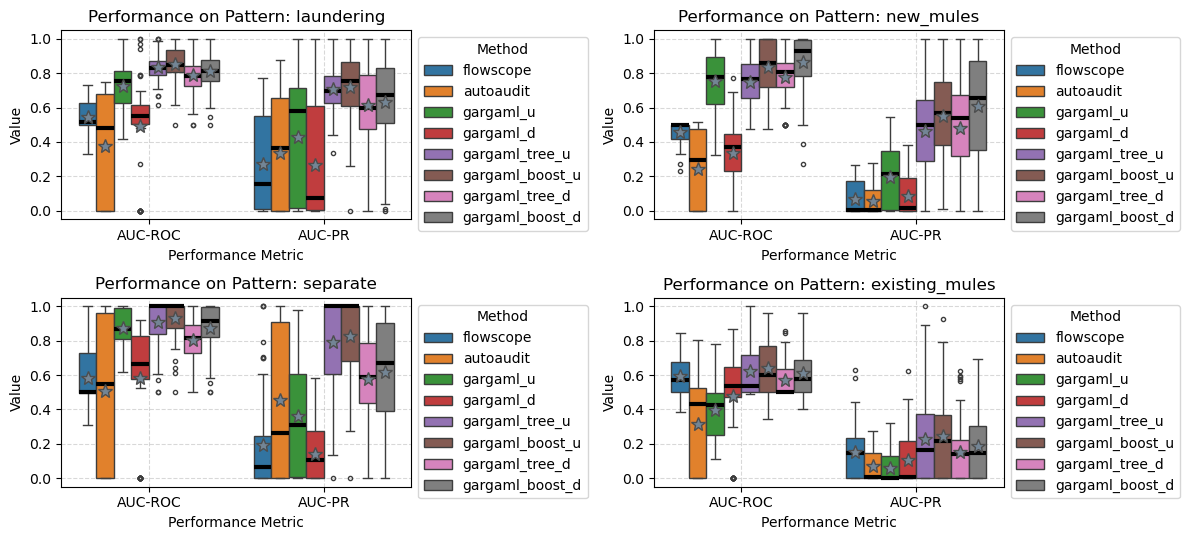

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5.5))
for i in range(2):
    for j in range(2): 
        pattern = patterns[i+2*j]

        sns.boxplot(ax=axes[i,j], x='performance_metric', y='performance', hue='method', data=df[df['pattern']==pattern], palette='tab10',fliersize=3, showmeans=True, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10}, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3})
        axes[i,j].set_title('Performance on Pattern: '+ pattern)
        axes[i,j].set_xlabel('Performance Metric')
        axes[i,j].set_ylabel('Value')
        axes[i,j].legend(title='method', bbox_to_anchor=(1.0, 1), loc='upper left')
        axes[i,j].grid(True,which="both",ls="--",c='gray', alpha=0.3)

        handles, labels = axes[i,j].get_legend_handles_labels()
        axes[i,j].legend(handles=handles,
                 #labels=['FlowScope', 'AutoAudit', 'GARG-AML', 'GARG-AML+Tree'],
                 title='Method',
                 bbox_to_anchor=(1.0, 1),
                 loc='upper left')

plt.tight_layout()

plt.savefig('../results/boxplot_performance_full.pdf')

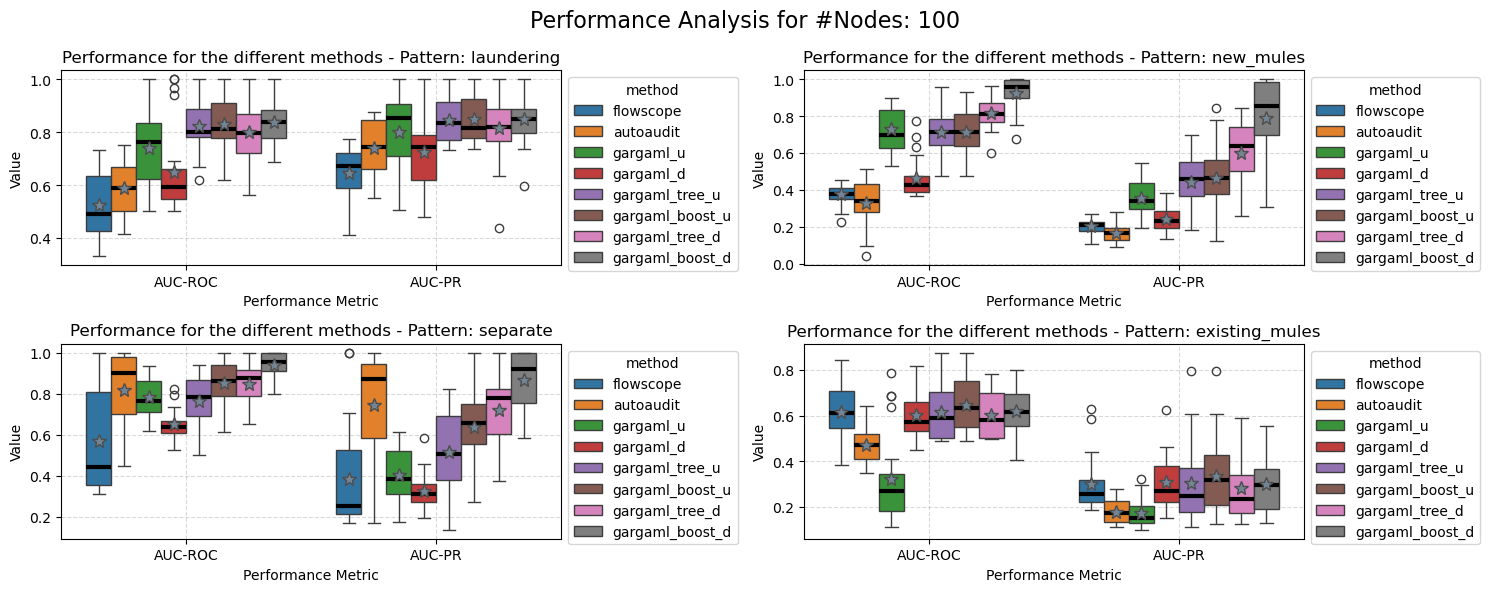

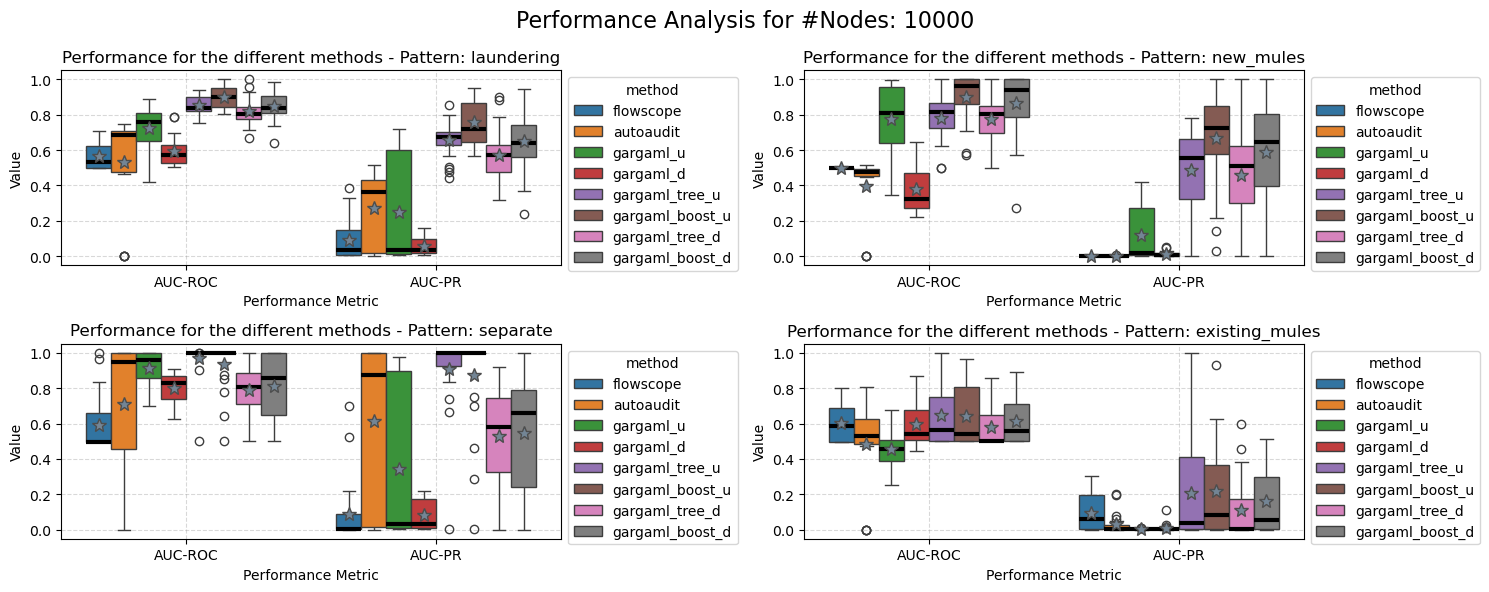

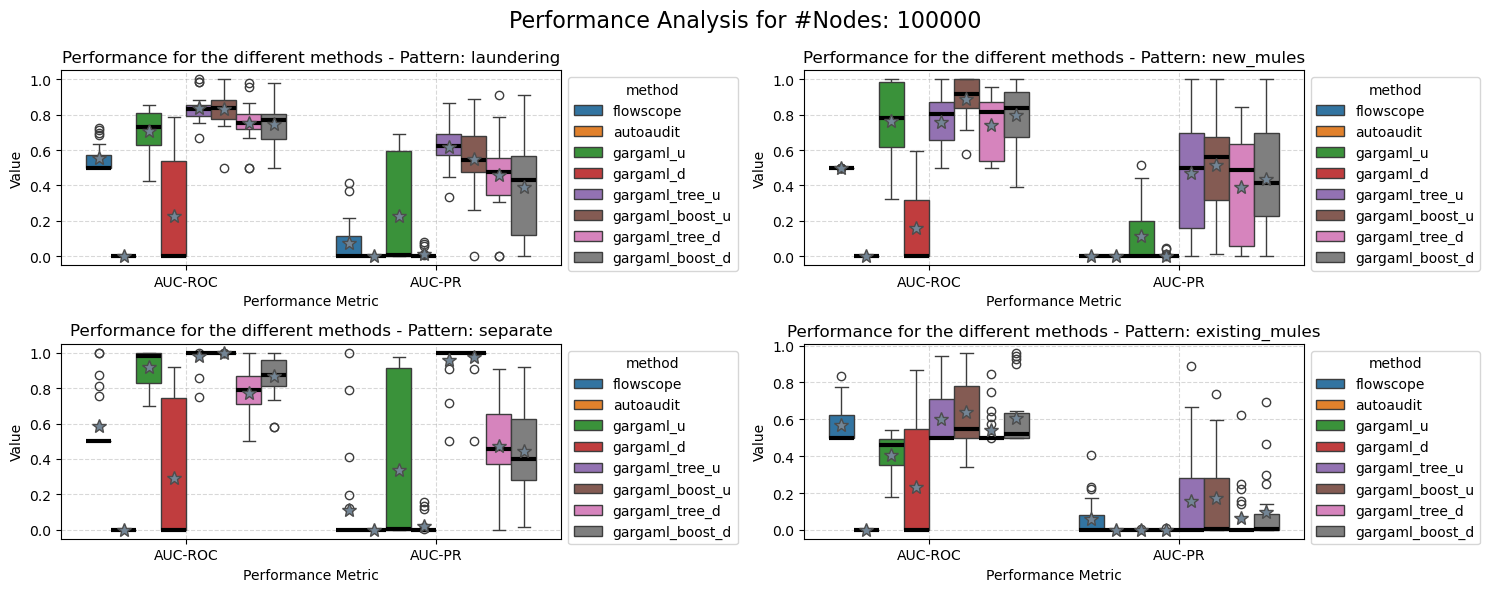

In [18]:
for n_nodes in n_nodes_list:
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))
    for i in range(2):
        for j in range(2): 
            pattern = patterns[i+2*j]

            sns.boxplot(ax=axes[i,j], x='performance_metric', y='performance', hue='method', data=df[(df['pattern']==pattern)&(df['dataset'].str.contains('_'+str(n_nodes)+'_'))], palette='tab10',showmeans=True, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10}, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3})
            axes[i,j].set_title('Performance for the different methods - Pattern: '+ pattern)
            axes[i,j].set_xlabel('Performance Metric')
            axes[i,j].set_ylabel('Value')
            axes[i,j].legend(title='method', bbox_to_anchor=(1.0, 1), loc='upper left')
            axes[i,j].grid(True,which="both",ls="--",c='gray', alpha=0.3)

    fig.suptitle(f'Performance Analysis for #Nodes: {n_nodes}', fontsize=16)
    plt.tight_layout()  # Adjust layout to fit the global title

    plt.savefig('../results/boxplot_performance_'+str(n_nodes)+'_full.pdf')

In [29]:
def give_order(models, pattern, dataset):
    # Initialize a dictionary to store the results
    results = {model: {'AUC-ROC': 0, 'AUC-PR': 0} for model in models}

    for model in models:
        results[model]['AUC-ROC'] = results_dict[dataset][model][pattern]['AUC-ROC']
        results[model]['AUC-PR'] = results_dict[dataset][model][pattern]['AUC-PR']

    sorted_models_ROC = []
    sorted_models_PR = []

    sorted_models_ROC_ = sorted(models, key=lambda model: results[model]['AUC-ROC'], reverse=True)
    sorted_models_PR_ = sorted(models, key=lambda model: results[model]['AUC-PR'], reverse=True)
    sorted_models_ROC.append(sorted_models_ROC_)
    sorted_models_PR.append(sorted_models_PR_)

    return sorted_models_ROC, sorted_models_PR

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/657204420.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx//2, idx%2].set_xticklabels(axes[idx//2, idx%2].get_xticklabels(),rotation=45)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/657204420.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx//2, idx%2].set_xticklabels(axes[idx//2, idx%2].get_xticklabels(),rotation=45)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/657204420.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx//2, idx%2].set_xticklabels(axes[idx//2, idx%2].get_xticklabels(),rotation=45)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/657204420.py:41: UserWarning: set_tick

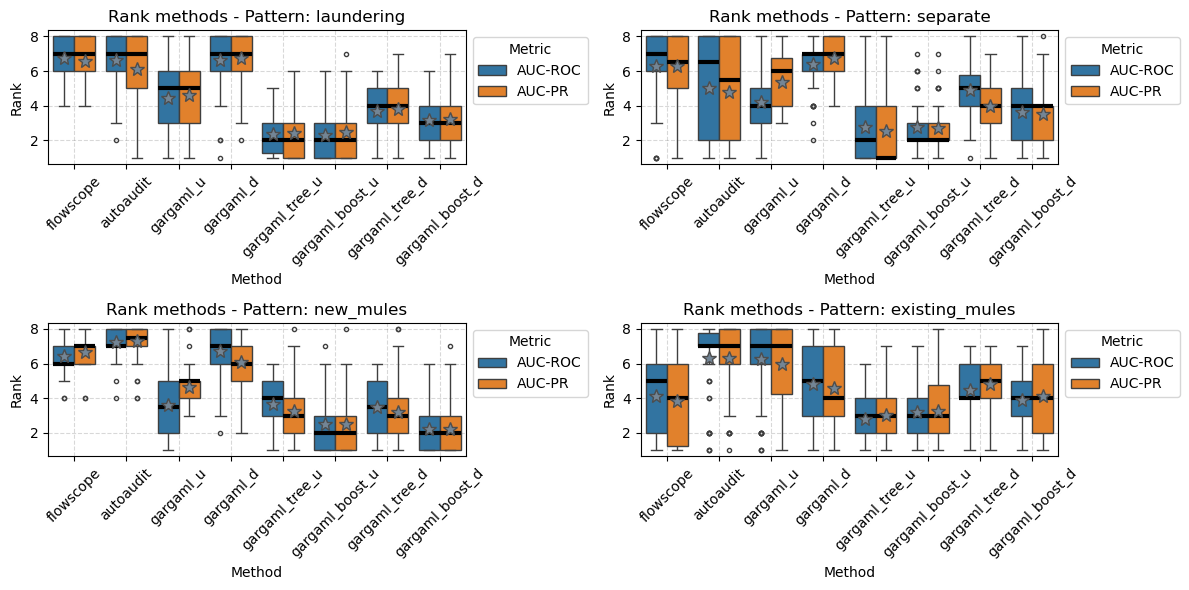

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for idx, pattern in enumerate(patterns):
    sorted_models_ROC_list = []
    sorted_models_PR_list = []

    for dataset in datasets:
        order_ROC, order_PR = give_order(models, pattern, dataset)
        for i in order_ROC:
            sorted_models_ROC_list.append(i)
        for i in order_PR:
            sorted_models_PR_list.append(i)
    
    dict_order_ROC = {}
    dict_order_PR = {}

    for model in models:
        dict_order_ROC[model] = []
        dict_order_PR[model] = []
        for i in sorted_models_ROC_list:
            dict_order_ROC[model].append(i.index(model) + 1)
        for i in sorted_models_PR_list:
            dict_order_PR[model].append(i.index(model) + 1)

    combined_data = []
    for model in models:
        for value in dict_order_ROC[model]:
            combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-ROC'})
        for value in dict_order_PR[model]:
            combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-PR'})
    
    combined_df = pd.DataFrame(combined_data)

    # Plot the boxplot
    sns.boxplot(ax=axes[idx//2, idx%2], x='Method', y='Rank', hue='Metric', data=combined_df,fliersize=3, palette='tab10', showmeans=True, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3}, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10})
    axes[idx//2, idx%2].set_title('Rank methods - Pattern: '+ pattern)
    axes[idx//2, idx%2].set_xlabel('Method')
    axes[idx//2, idx%2].set_ylabel('Rank')
    axes[idx//2, idx%2].legend(title='Metric', bbox_to_anchor=(1.0, 1), loc='upper left')
    axes[idx//2, idx%2].grid(True,which="both",ls="--",c='gray', alpha=0.3)  
    axes[idx//2, idx%2].set_xticklabels(axes[idx//2, idx%2].get_xticklabels(),rotation=45)
    #axes[idx//2, idx%2].set_xticklabels(['FlowScope', 'AutoAudit', 'GARG-AML', 'GARG-AML+Tree'])

plt.tight_layout()
plt.savefig('../results/boxplot_rank_full.pdf')

    

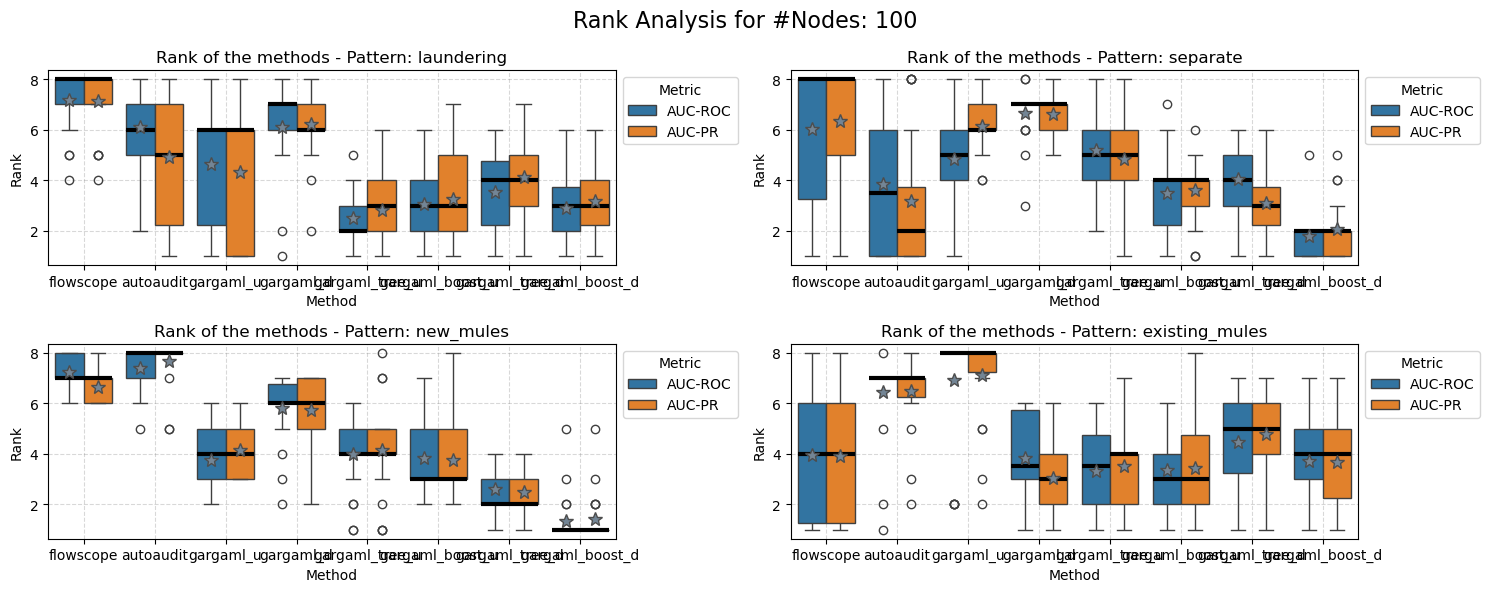

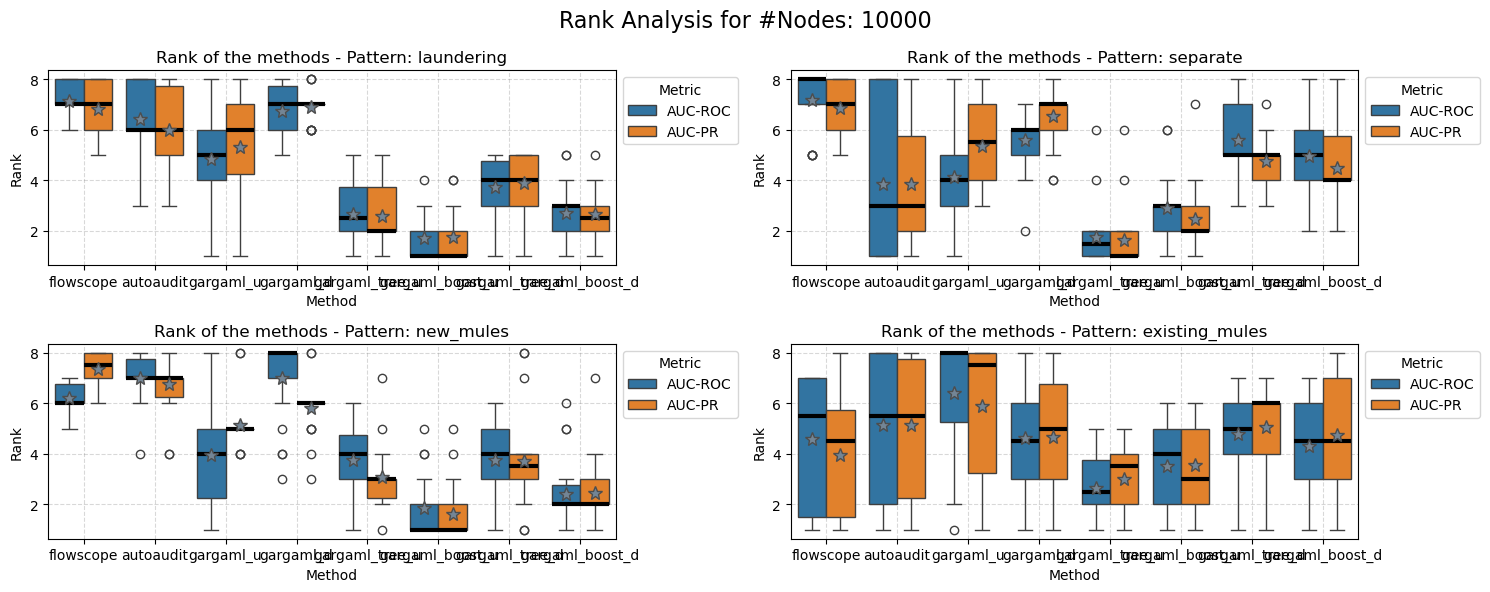

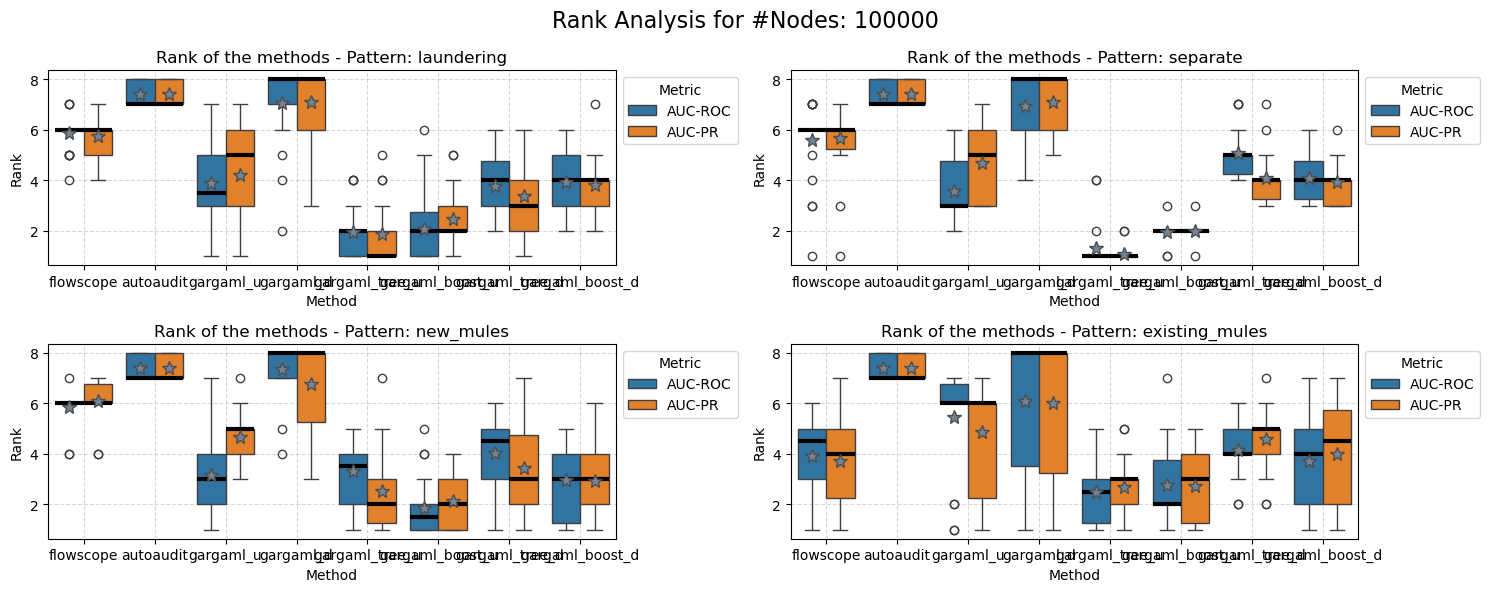

In [21]:
for n_nodes in n_nodes_list:
    datasets_nodes = [dataset for dataset in datasets if dataset.split('_')[2] == str(n_nodes)]    
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))

    for idx, pattern in enumerate(patterns):
        sorted_models_ROC_list = []
        sorted_models_PR_list = []

        for dataset in datasets_nodes:
            order_ROC, order_PR = give_order(models, pattern, dataset)
            for i in order_ROC:
                sorted_models_ROC_list.append(i)
            for i in order_PR:
                sorted_models_PR_list.append(i)
        
        dict_order_ROC = {}
        dict_order_PR = {}

        for model in models:
            dict_order_ROC[model] = []
            dict_order_PR[model] = []
            for i in sorted_models_ROC_list:
                dict_order_ROC[model].append(i.index(model) + 1)
            for i in sorted_models_PR_list:
                dict_order_PR[model].append(i.index(model) + 1)

        combined_data = []
        for model in models:
            for value in dict_order_ROC[model]:
                combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-ROC'})
            for value in dict_order_PR[model]:
                combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-PR'})
        
        combined_df = pd.DataFrame(combined_data)

        # Plot the boxplot
        sns.boxplot(ax=axes[idx//2, idx%2], x='Method', y='Rank', hue='Metric', data=combined_df, palette='tab10', showmeans=True, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3}, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10})
        axes[idx//2, idx%2].set_title('Rank of the methods - Pattern: '+ pattern)
        axes[idx//2, idx%2].set_xlabel('Method')
        axes[idx//2, idx%2].set_ylabel('Rank')
        axes[idx//2, idx%2].legend(title='Metric', bbox_to_anchor=(1.0, 1), loc='upper left')
        axes[idx//2, idx%2].grid(True,which="both",ls="--",c='gray', alpha=0.3)  
    fig.suptitle(f'Rank Analysis for #Nodes: {n_nodes}', fontsize=16)
    plt.tight_layout()
    plt.savefig('boxplot_rank_'+str(n_nodes)+'_full.pdf')


## Statistical test of the ranks

Two statistical tests are applied. First, the Friedman test is used to test if there are statistically significant differences in the mean ranks of the methods. If there is, we apply the post-hoc Nemenyi test to compare the methods two-by-two and to construct the critical distance diagrams. 

In [ ]:
import numpy as np
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import matplotlib.pyplot as plt

### Friedman Test

Friedman test statistic: 6.8333, p-value: 0.1450
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [2.5        2.16666667 4.         3.83333333 2.5       ]


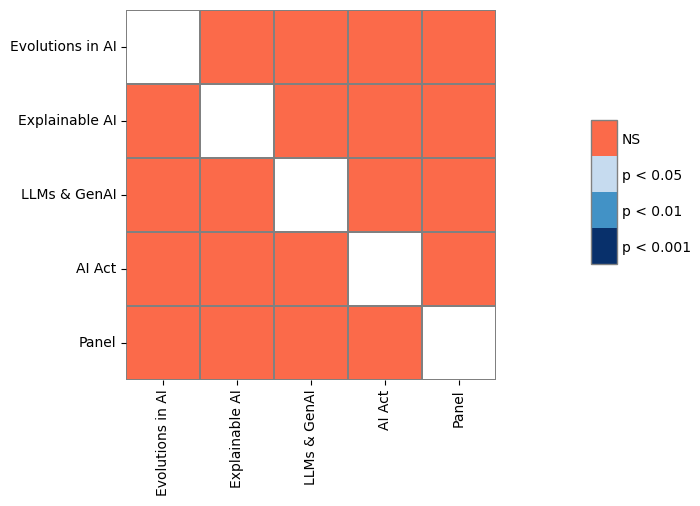

In [7]:
# Example scores of 6 classifiers over 5 datasets
# Rows = datasets, Columns = models
scores = np.array([
    [3.00, 2.00, 4.00, 5.00, 1.00],
    [2.00, 2.00, 2.00, 2.00, 2.00],
    [5.00, 3.00, 4.00, 2.00, 1.00],
    [3.00, 1.00, 5.00, 4.00, 2.00],
    [1.00, 2.00, 4.00, 3.00, 5.00],
    [2.00, 2.00, 2.00, 3.00, 1.00],
])

# Run the Friedman test
stat, p = friedmanchisquare(*scores.T)

print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

if p < 0.2:
    print("Significant differences found — proceeding with Critical Distance Diagram")

    # Compute ranks (1 = best, higher = worse)
    ranks = np.argsort(np.argsort(scores, axis=1), axis=1) + 1  # ascending order

    # Average ranks per model
    avg_ranks = np.mean(ranks, axis=0)
    print("Average ranks:", avg_ranks)

    nf = sp.posthoc_nemenyi_friedman(scores)
    nf.index=['Evolutions in AI','Explainable AI','LLMs & GenAI', 'AI Act', 'Panel']
    nf.columns=['Evolutions in AI','Explainable AI','LLMs & GenAI', 'AI Act', 'Panel']
    # Format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
    cmap = ['1', '#fb6a4a',  '#08306b',  '#4292c6', '#c6dbef']
    heatmap_args = {'cmap': cmap, 'linewidths': 0.25, 'linecolor': '0.5', 'square': True}
    sp.sign_plot(nf, **heatmap_args)

else:
    print("No statistically significant differences found — skipping post-hoc analysis.")


{'markers': [<matplotlib.collections.PathCollection at 0x3294014d0>,
 'elbows': [<matplotlib.lines.Line2D at 0x32967f250>,
 'labels': [Text(2.1566666666666667, -2, 'Explainable AI (2.2)'),
  Text(2.1566666666666667, -3, 'Evolutions in AI (2.5)'),
  Text(4.01, -2, '(4) LLMs & GenAI'),
  Text(4.01, -3, '(3.8) AI Act'),
  Text(4.01, -4, '(2.5) Panel')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x32946e790>]]}

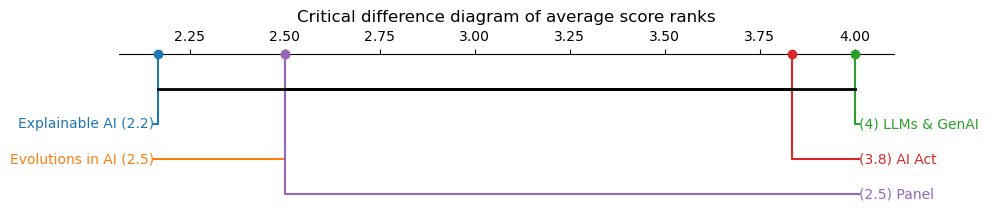

In [8]:
avg_ranks_dict = {}
for i, model in enumerate(nf.index):
    avg_ranks_dict[model] = avg_ranks[i]
avg_ranks_dict
plt.figure(figsize=(10, 2))
plt.title('Critical difference diagram of average score ranks')
sp.critical_difference_diagram(avg_ranks_dict, nf)

In [25]:
df_selection = df[(df['pattern']=='laundering')&(df['performance_metric']=='AUC-ROC')][['dataset', 'method', 'performance']]
avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()
avg_rank

method
autoaudit          6.734848
flowscope          6.742424
gargaml_boost_d    3.037879
gargaml_boost_u    2.166667
gargaml_d          6.575758
gargaml_tree_d     3.666667
gargaml_tree_u     2.568182
gargaml_u          4.507576
Name: performance, dtype: float64

In [26]:
df_selection

,dataset,method,performance
0,synthetic_Barabasi-Albert_100_1_0_3,flowscope,0.660428
8,synthetic_Barabasi-Albert_100_1_0_3,autoaudit,0.562643
16,synthetic_Barabasi-Albert_100_1_0_3,gargaml_u,0.561688
24,synthetic_Barabasi-Albert_100_1_0_3,gargaml_d,0.674561
32,synthetic_Barabasi-Albert_100_1_0_3,gargaml_tree_u,0.815735
...,...,...,...
4184,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_d,0.000000
4192,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_tree_u,0.838235
4200,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_boost_u,0.852791
4208,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_tree_d,0.779412


In [27]:
dict_data = {}
for method in models:
    dict_data[method] = []
    for dataset in datasets:
        dict_data[method].append(results_dict[dataset][method]['laundering']['AUC-ROC'])

In [28]:
df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

method
autoaudit          6.734848
flowscope          6.742424
gargaml_boost_d    3.037879
gargaml_boost_u    2.166667
gargaml_d          6.575758
gargaml_tree_d     3.666667
gargaml_tree_u     2.568182
gargaml_u          4.507576
Name: performance, dtype: float64

Friedman test statistic: 295.2842, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.72727273 6.63636364 4.46969697 6.62121212 2.37878788 2.28787879
 3.68181818 3.1969697 ]


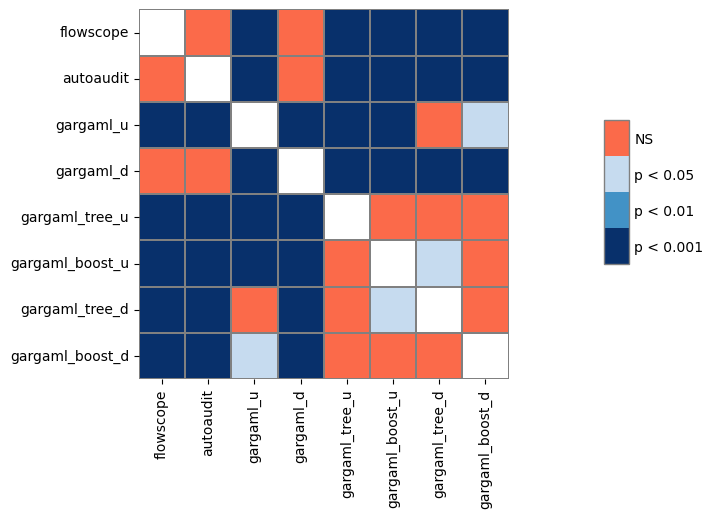

In [29]:
scores = np.array(list(dict_data.values())).T

# Run the Friedman test
stat, p = friedmanchisquare(*scores.T)

print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

if p<0.05:
    print("Significant differences found — proceeding with Critical Distance Diagram")

    # Compute ranks (1 = best, higher = worse)
    ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

    # Average ranks per model
    avg_ranks = np.mean(ranks, axis=0)
    print("Average ranks:", avg_ranks)

    nf = sp.posthoc_nemenyi_friedman(scores)
    model_names = list(dict_data.keys())
    nf.index=nf.columns=model_names
    
    # Format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
    cmap = ['1', '#fb6a4a',  '#08306b',  '#4292c6', '#c6dbef']
    heatmap_args = {'cmap': cmap, 'linewidths': 0.25, 'linecolor': '0.5', 'square': True}
    sp.sign_plot(nf, **heatmap_args)

else:
    print("No statistically significant differences found — skipping post-hoc analysis.")


{'markers': [<matplotlib.collections.PathCollection at 0x32d285190>,
 'elbows': [<matplotlib.lines.Line2D at 0x32c904990>,
 'labels': [Text(2.1566666666666667, -3, 'GARG-AML Boost Undir. [2.17]  '),
  Text(2.1566666666666667, -4, 'GARG-AML Tree Undir. [2.57]  '),
  Text(2.1566666666666667, -5, 'GARG-AML Boost Dir. [3.04]  '),
  Text(2.1566666666666667, -6, 'GARG-AML Tree Dir. [3.67]  '),
  Text(6.752424242424242, -3, '  [6.74] FlowScope'),
  Text(6.752424242424242, -4, '  [6.73] AutoAudit'),
  Text(6.752424242424242, -5, '  [6.58] GARG-AML Dir.'),
  Text(6.752424242424242, -6, '  [4.51] GARG-AML')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x32c915090>],
  [<matplotlib.lines.Line2D at 0x329613750>]]}

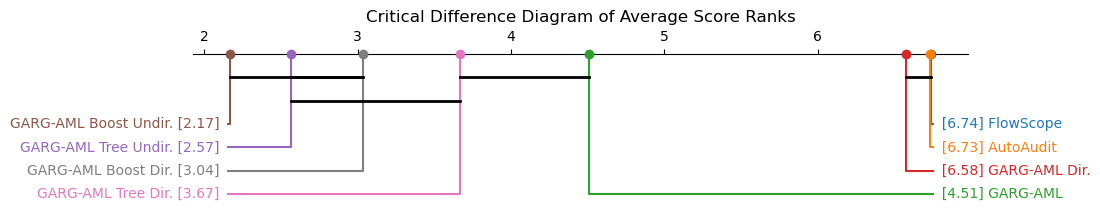

In [30]:
# Define the colors for the models based on their order in the boxplot
model_colors = {
    'flowscope': 'tab:blue',
    'autoaudit': 'tab:orange',
    'gargaml_u': 'tab:green',
    'gargaml_d': 'tab:red', 
    'gargaml_tree_u': 'tab:purple',
    'gargaml_boost_u': 'tab:brown', 
    'gargaml_tree_d': 'tab:pink',
    'gargaml_boost_d': 'tab:gray'
}

pretty_model_names = {
'flowscope': 'FlowScope',
   'autoaudit': 'AutoAudit',
   'gargaml_u': 'GARG-AML',
   'gargaml_d': 'GARG-AML Dir.', 
   'gargaml_tree_u': 'GARG-AML Tree Undir.',
   'gargaml_boost_u': 'GARG-AML Boost Undir.',
   'gargaml_tree_d': 'GARG-AML Tree Dir.',
   'gargaml_boost_d': 'GARG-AML Boost Dir.'
}



avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

# --- IMPORTANT: Create a new dictionary with PRETTY labels ---
avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

# Also adapt the color palette using pretty labels
color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}

# Now plot with pretty names
plt.figure(figsize=(10, 2))
plt.title('Critical Difference Diagram of Average Score Ranks')
sp.critical_difference_diagram(
    ranks=avg_ranks_pretty,
    #ranks=avg_ranks_dict,
    sig_matrix=nf,  # Assuming nf matches the order of avg_ranks_dict
    label_fmt_left='{label} [{rank:.2f}]  ',
    label_fmt_right='  [{rank:.2f}] {label}',
    color_palette=color_palette_pretty,
    #color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()}
)

Friedman test statistic: 295.2842, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.72727273 6.63636364 4.46969697 6.62121212 2.37878788 2.28787879
 3.68181818 3.1969697 ]
Friedman test statistic: 163.8799, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.27272727 5.04545455 4.1969697  6.40909091 2.75757576 2.78787879
 4.90909091 3.62121212]
Friedman test statistic: 314.5559, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.43939394 7.27272727 3.63636364 6.72727273 3.6969697  2.51515152
 3.46969697 2.24242424]
Friedman test statistic: 123.9472, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [4.15151515 6.33333333 6.25757576 4.84848485 2.81818182 3.21212121
 4.45454545 3.92424242]


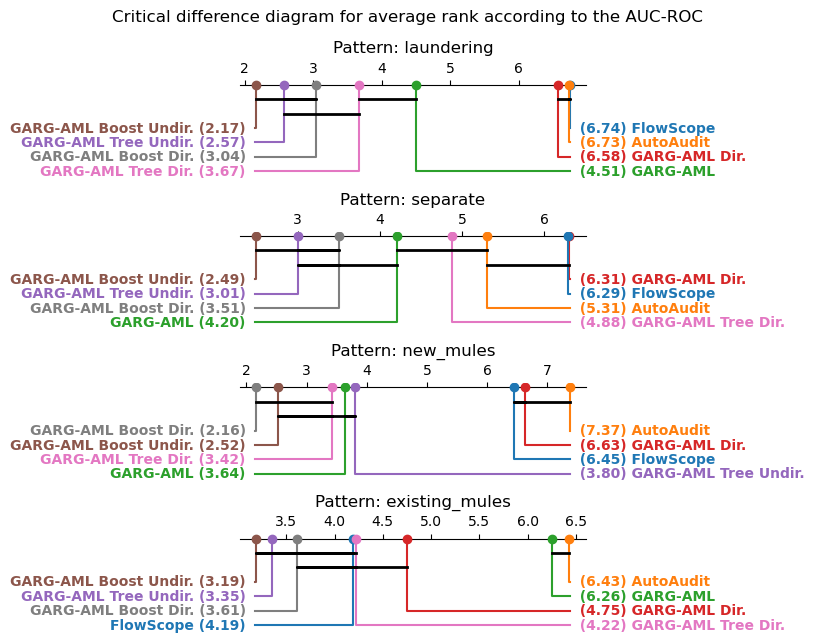

In [31]:
fig, axes = plt.subplots(4, 1, figsize=(8, 6.5))

for i_ax in range(4):
    pattern = patterns[i_ax]

    df_selection = df[(df['pattern']==pattern)&(df['performance_metric']=='AUC-ROC')][['dataset', 'method', 'performance']]
    avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

    dict_data = {}
    for method in models:
        dict_data[method] = []
        for dataset in datasets:
            dict_data[method].append(results_dict[dataset][method][pattern]['AUC-ROC'])        

    scores = np.array(list(dict_data.values())).T

    # Run the Friedman test
    stat, p = friedmanchisquare(*scores.T)

    print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

    if p<0.05:
        print("Significant differences found — proceeding with Critical Distance Diagram")

        # Compute ranks (1 = best, higher = worse)
        ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

        # Average ranks per model
        avg_ranks = np.mean(ranks, axis=0)
        print("Average ranks:", avg_ranks)

        nf = sp.posthoc_nemenyi_friedman(scores)
        model_names = list(dict_data.keys())
        nf.index=nf.columns=model_names

        avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

        # --- IMPORTANT: Create a new dictionary with PRETTY labels ---
        avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
        nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

        # Also adapt the color palette using pretty labels
        color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}
        
        axes[i_ax].set_title('Pattern: '+pattern)
        sp.critical_difference_diagram(
            ranks=avg_ranks_pretty,
            # ranks=avg_ranks_dict,
            sig_matrix=nf,
            label_fmt_left='{label} ({rank:.2f})  ',
            label_fmt_right='  ({rank:.2f}) {label}',
            label_props={'fontweight': 'bold'},
            color_palette= color_palette_pretty, 
            # color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()},
            ax=axes[i_ax]
            )
        
        # Get correct handles and labels
        handles, labels = axes[i_ax].get_legend_handles_labels()

    else:
        print("No statistically significant differences found — skipping post-hoc analysis.")

plt.suptitle('Critical difference diagram for average rank according to the AUC-ROC')
plt.tight_layout()
plt.savefig('../results/CD_ROC_full.pdf')

Friedman test statistic: 250.7805, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.57575758 6.10606061 4.62121212 6.74242424 2.42424242 2.5
 3.8030303  3.22727273]
Friedman test statistic: 197.7439, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.3030303  4.81818182 5.39393939 6.75757576 2.53030303 2.6969697
 3.98484848 3.51515152]
Friedman test statistic: 307.9389, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.6969697  7.28787879 4.65151515 6.10606061 3.25757576 2.51515152
 3.22727273 2.25757576]
Friedman test statistic: 106.1874, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [3.86363636 6.34848485 5.96969697 4.57575758 3.06060606 3.24242424
 4.8030303  4.13636364]


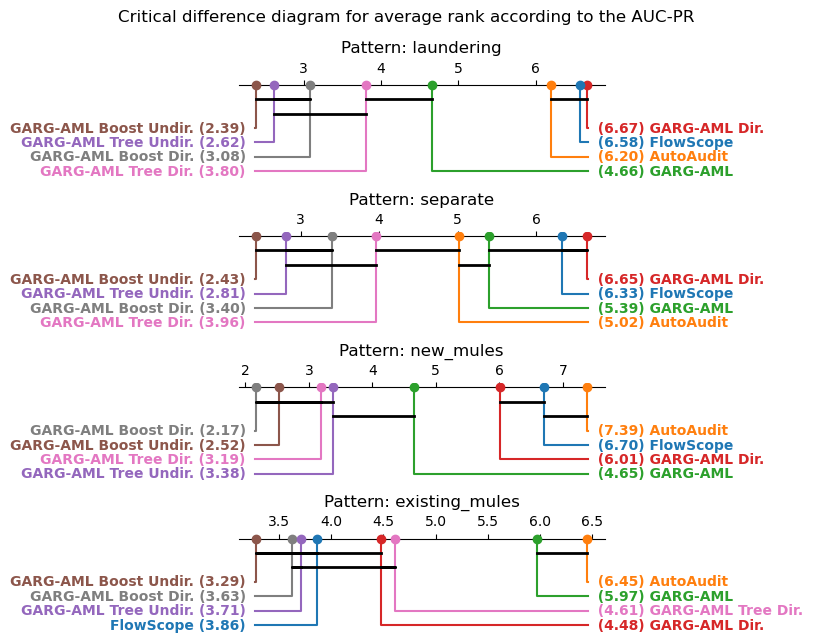

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(8, 6.5))

for i_ax in range(4):
    pattern = patterns[i_ax]

    df_selection = df[(df['pattern']==pattern)&(df['performance_metric']=='AUC-PR')][['dataset', 'method', 'performance']]
    avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

    dict_data = {}
    for method in models:
        dict_data[method] = []
        for dataset in datasets:
            dict_data[method].append(results_dict[dataset][method][pattern]['AUC-PR'])        

    scores = np.array(list(dict_data.values())).T

    # Run the Friedman test
    stat, p = friedmanchisquare(*scores.T)

    print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

    if p<0.05:
        print("Significant differences found — proceeding with Critical Distance Diagram")

        # Compute ranks (1 = best, higher = worse)
        ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

        # Average ranks per model
        avg_ranks = np.mean(ranks, axis=0)
        print("Average ranks:", avg_ranks)

        nf = sp.posthoc_nemenyi_friedman(scores)
        model_names = list(dict_data.keys())
        nf.index=nf.columns=model_names

        avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

        # --- IMPORTANT: Create a new dictionary with PRETTY labels ---
        avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
        nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

        # Also adapt the color palette using pretty labels
        color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}

        axes[i_ax].set_title('Pattern: '+pattern)
        sp.critical_difference_diagram(
            ranks=avg_ranks_pretty,
            # ranks=avg_ranks_dict,
            sig_matrix=nf,
            label_fmt_left='{label} ({rank:.2f})  ',
            label_fmt_right='  ({rank:.2f}) {label}',
            label_props={'fontweight': 'bold'},
            color_palette= color_palette_pretty, 
            # color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()},
            ax=axes[i_ax]
            )
    else:
        print("No statistically significant differences found — skipping post-hoc analysis.")

plt.suptitle('Critical difference diagram for average rank according to the AUC-PR')
plt.tight_layout()
plt.savefig('../results/CD_PR_full.pdf')

# IBM Dataset

In this part of the notebook, we analyse the results for the IBM data set. 

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [35]:
# GARG-AML Undirected
file = '../results/results_performance_IBM_undirected.txt'
with open(file, 'r') as f:
    lines = f.readlines()

model_list = []
dataset_list = []
pattern_list = []
cutoff_list = []
AUCROC_list = []
AUCPR_list = []

for line in lines:
    long_split = line.strip().split('_')
    model = 'GARG-AML Undirected'
    dataset = long_split[0]
    pattern = long_split[1]
    cutoff_results = long_split[2].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)


In [36]:
# GARG-AML Directed
file = '../results/results_performance_IBM_directed.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    model = 'GARG-AML Directed'
    dataset = long_split[0]
    pattern = long_split[1]
    cutoff_results = long_split[2].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

In [37]:
# Flowscope HI-Small
file = '../results/flowscope_performance_HI-Small.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    model = 'FlowScope'
    dataset = 'HI-Small'
    pattern = long_split[1]
    cutoff_results = long_split[3].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

In [38]:
# Flowscope LI-Large
file = '../results/flowscope_performance_LI-Large.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    print(long_split)
    model = 'FlowScope'
    dataset = 'LI-Large'
    pattern = long_split[1]
    cutoff_results = long_split[3].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

['Pattern', 'Is Laundering', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978048234371, 0.002161712235748811])']
['Pattern', 'FAN-OUT', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780945788463, 5.062329937353667e-05])']
['Pattern', 'FAN-IN', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094600173, 4.9649774385584044e-05])']
['Pattern', 'GATHER-SCATTER', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094035006, 7.54481865663287e-05])']
['Pattern', 'SCATTER-GATHER', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978092477979, 0.00014651551068687056])']
['Pattern', 'CYCLE', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780938110633, 8.56701989398313e-05])']
['Pattern', 'RANDOM', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780944722133, 5.5490924313299815e-05])']
['Pattern', 'BIPARTITE', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094802773, 4.040128700003407e-05])']
['Pattern', 'STACK', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978093597781, 9.540544881935757e-05])']
['Pattern', 'Is Laundering', 'Cutoff

In [39]:
models_IBM_tree = ['tree', 'boosting']
directed_list = ['undirected', 'directed']
IMB_data_list = ['HI-Small', 'LI-Large']
metrics_list = ['ROC', 'PR']
IBM_cutoffs = [0.1, 0.2, 0.3, 0.5, 0.9]
IBM_patterns = ['Is Laundering', 'FAN-OUT', 'FAN-IN', 'GATHER-SCATTER', 'SCATTER-GATHER', 'CYCLE', 'RANDOM', 'BIPARTITE', 'STACK']

for ds in IMB_data_list:
    for d in directed_list:
        for m in models_IBM_tree:
            for cut_off in IBM_cutoffs:
                for pattern in IBM_patterns:
                    model_list.append('GARG-AML '+d.capitalize()+' '+m.capitalize())
                    dataset_list.append(ds)
                    pattern_list.append(pattern)
                    cutoff_list.append(str(cut_off))
                    for pm in metrics_list:
                        file = '../results/'+ds+'_AUC_'+pm+'_'+m+'_'+d+'_combined.csv'
                        df = pd.read_csv(file, index_col=0)
                        if pm == 'ROC':
                            AUC = df.loc[cut_off][pattern]
                            AUCROC_list.append(AUC)
                        else:
                            AUC = df.loc[cut_off][pattern]
                            AUCPR_list.append(AUC)



In [41]:
results_df = pd.DataFrame({
    'model': model_list,
    'dataset': dataset_list,
    'pattern': pattern_list,
    'cutoff': cutoff_list,
    'AUC-ROC': AUCROC_list,
    'AUC-PR': AUCPR_list
})

In [42]:
results_df.fillna(0, inplace=True)

In [43]:
results_df.tail()

,model,dataset,pattern,cutoff,AUC-ROC,AUC-PR
625,GARG-AML Directed Boosting,LI-Large,SCATTER-GATHER,0.9,0.0,0.0
626,GARG-AML Directed Boosting,LI-Large,CYCLE,0.9,0.0,0.0
627,GARG-AML Directed Boosting,LI-Large,RANDOM,0.9,0.0,0.0
628,GARG-AML Directed Boosting,LI-Large,BIPARTITE,0.9,0.0,0.0
629,GARG-AML Directed Boosting,LI-Large,STACK,0.9,0.0,0.0


In [44]:
results_plot_df = results_df[(results_df['dataset']==dataset) & (results_df['pattern'].isin(['Is Laundering', 'GATHER-SCATTER', 'SCATTER-GATHER'])) & (results_df['cutoff'].isin(['0.1', '0.5' ,'0.9']))]

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/1812754157.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, ylim_max)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/1812754157.py:45: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, ylim_max_2)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/1812754157.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, ylim_max)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/1812754157.py:45: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, ylim_max_2)


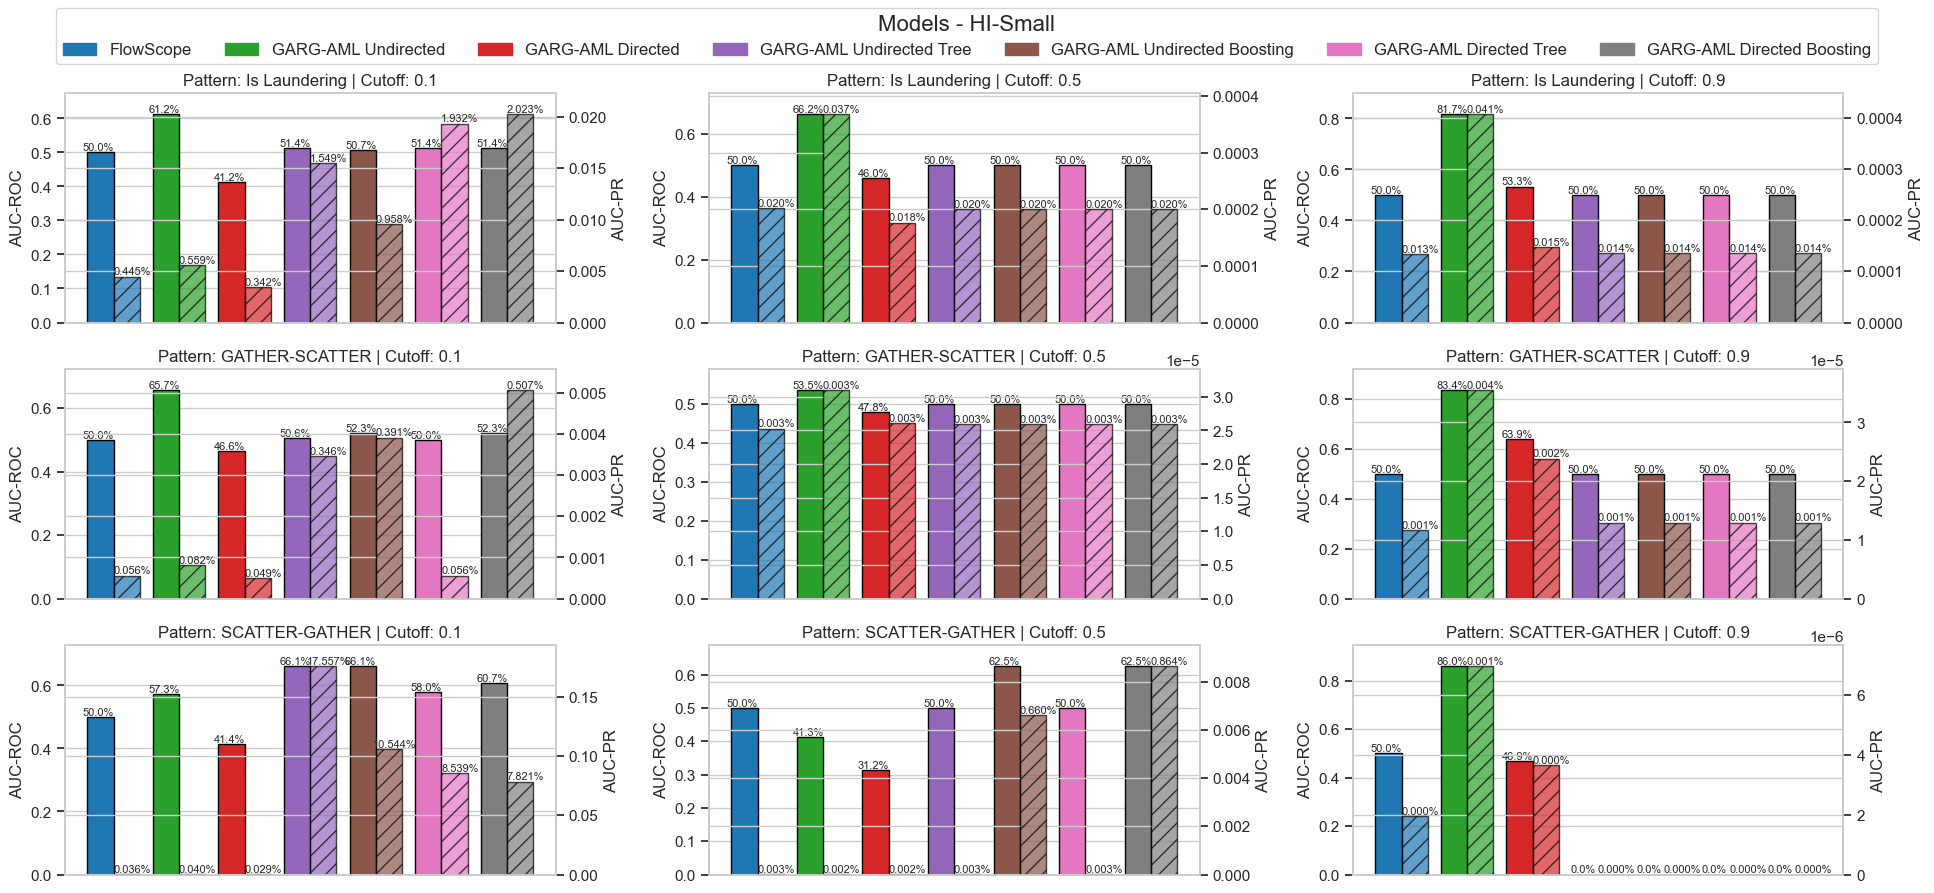

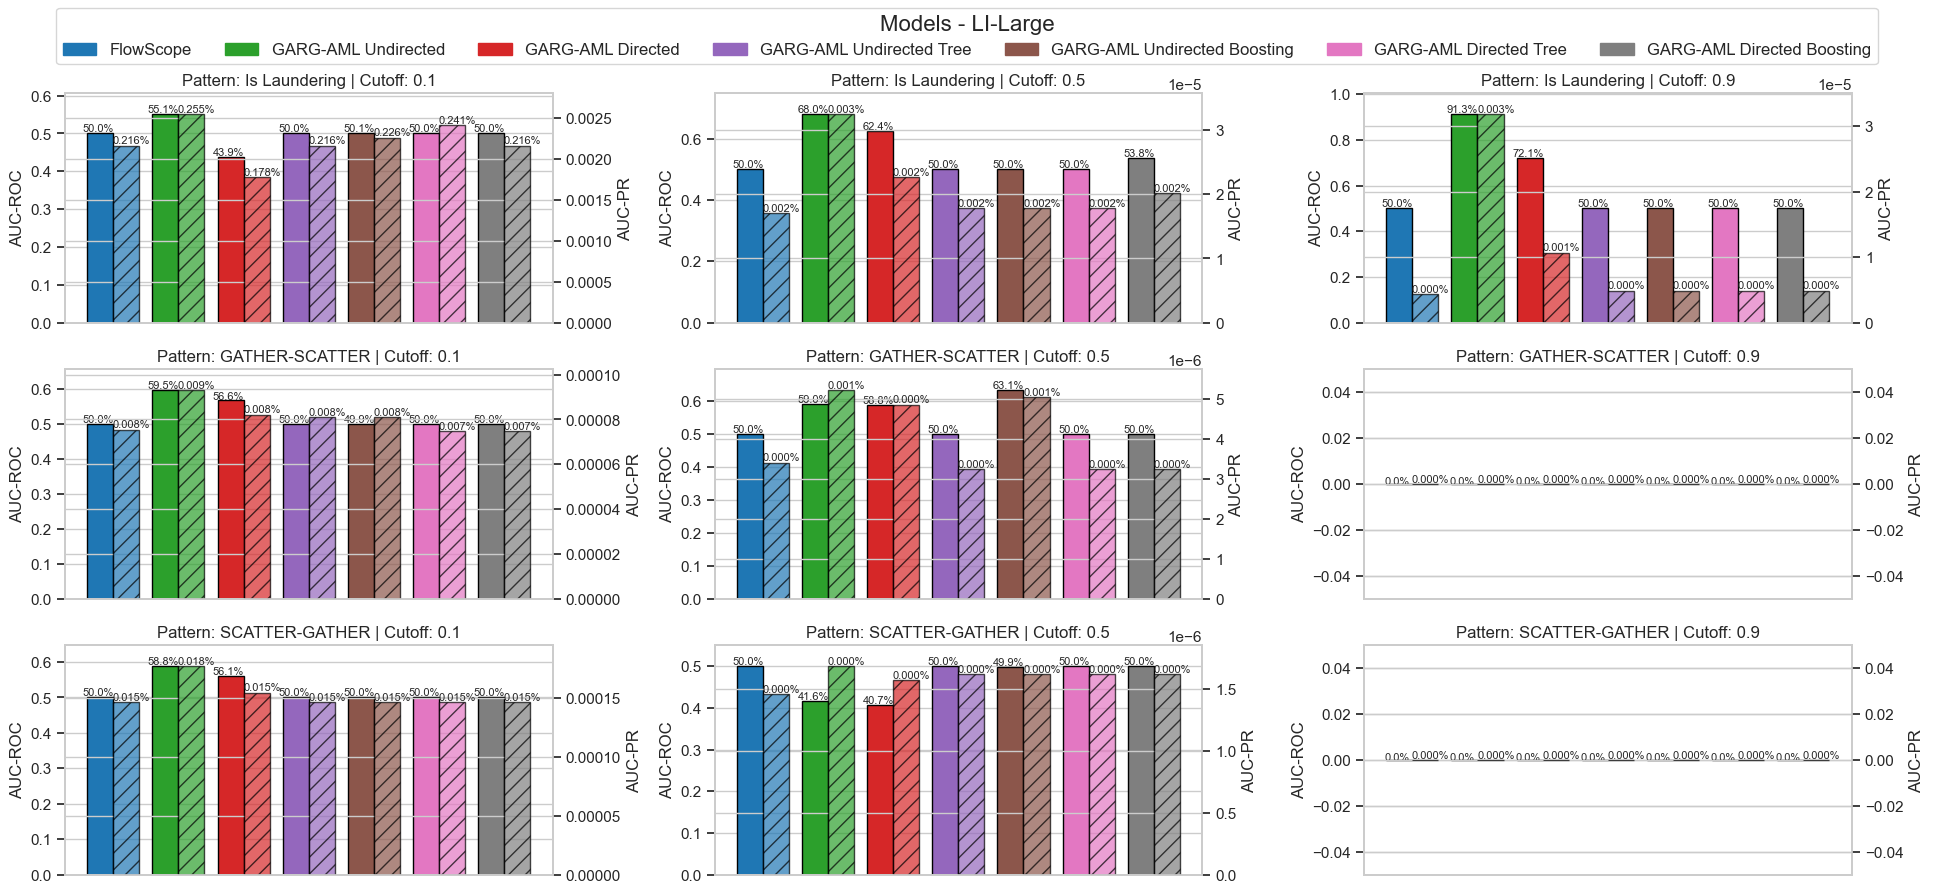

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = ['HI-Small', 'LI-Large']
for dataset in datasets:
    results_plot_df = results_df[(results_df['dataset']==dataset) & (results_df['pattern'].isin(['Is Laundering', 'GATHER-SCATTER', 'SCATTER-GATHER'])) & (results_df['cutoff'].isin(['0.1', '0.5' ,'0.9']))]

    # Ensure consistent aesthetics
    sns.set(style="whitegrid")

    # Assume results_plot_df is already defined
    # Extract unique patterns and cutoffs
    patterns = results_plot_df['pattern'].unique()
    cutoffs = results_plot_df['cutoff'].unique()
    models = ['FlowScope','GARG-AML Undirected', 'GARG-AML Directed',
       'GARG-AML Undirected Tree', 'GARG-AML Undirected Boosting',
       'GARG-AML Directed Tree', 'GARG-AML Directed Boosting']
    palette = sns.color_palette("tab10", len(models)+1)
    del (palette[1])

    # Create a mapping from model names to colors
    model_color_map = dict(zip(models, palette))

    # Create the subplot grid
    fig, axes = plt.subplots(len(patterns), len(cutoffs), figsize=(6.5 * len(cutoffs), 3 * len(patterns)), squeeze=False)

    for i, pattern in enumerate(patterns):
        for j, cutoff in enumerate(cutoffs):
            ax = axes[i, j]
            subset = results_plot_df[(results_plot_df['pattern'] == pattern) & (results_plot_df['cutoff'] == cutoff)]
            ylim_max = subset['AUC-ROC'].max()*1.1
            ax.set_ylim(0, ylim_max)
            # Primary bar plot for AUC-ROC
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                roc = model_data['AUC-ROC'].values[0]
                ax.bar(idx - 0.2, model_data['AUC-ROC'], width=0.4, label=model if i == 0 and j == 0 else "", 
                    color=model_color_map[model], edgecolor='black')
                ax.text(idx - 0.23, roc-0.001, f"{roc*100:.1f}%", ha='center', va='bottom', fontsize=8)
            
            # Twin axis for AUC-PR
            ylim_max_2 = subset['AUC-PR'].max()*1.1
            ax2 = ax.twinx()
            ax2.set_ylim(0, ylim_max_2)
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                pr = model_data['AUC-PR'].values[0]
                ax2.bar(idx + 0.2, model_data['AUC-PR'], width=0.4, label=None, 
                        color=model_color_map[model], hatch='//', alpha=0.7, edgecolor='black')
                ax2.text(idx + 0.28, pr, f"{pr*100:.3f}%", ha='center', va='bottom', fontsize=8)

            ax.set_title(f"Pattern: {pattern} | Cutoff: {cutoff}")
            ax.set_xticks([])
            ax.set_xticklabels([])
            ax.set_ylabel("AUC-ROC")
            ax2.set_ylabel("AUC-PR")

    # Add legend only once
    handles = [plt.Rectangle((0,0),1,1, color=model_color_map[m]) for m in models]
    fig.legend(handles, models, loc='upper center', ncol=len(models), title='Models - '+dataset, fontsize=12, title_fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig('../results/'+dataset+'_AUC-ROC_AUC-PR.pdf')

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/3412479748.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, ylim_max)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/3412479748.py:45: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, ylim_max_2)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/3412479748.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, ylim_max)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/3412479748.py:45: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, ylim_max_2)
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_30096/3412479748.py:33: UserWar

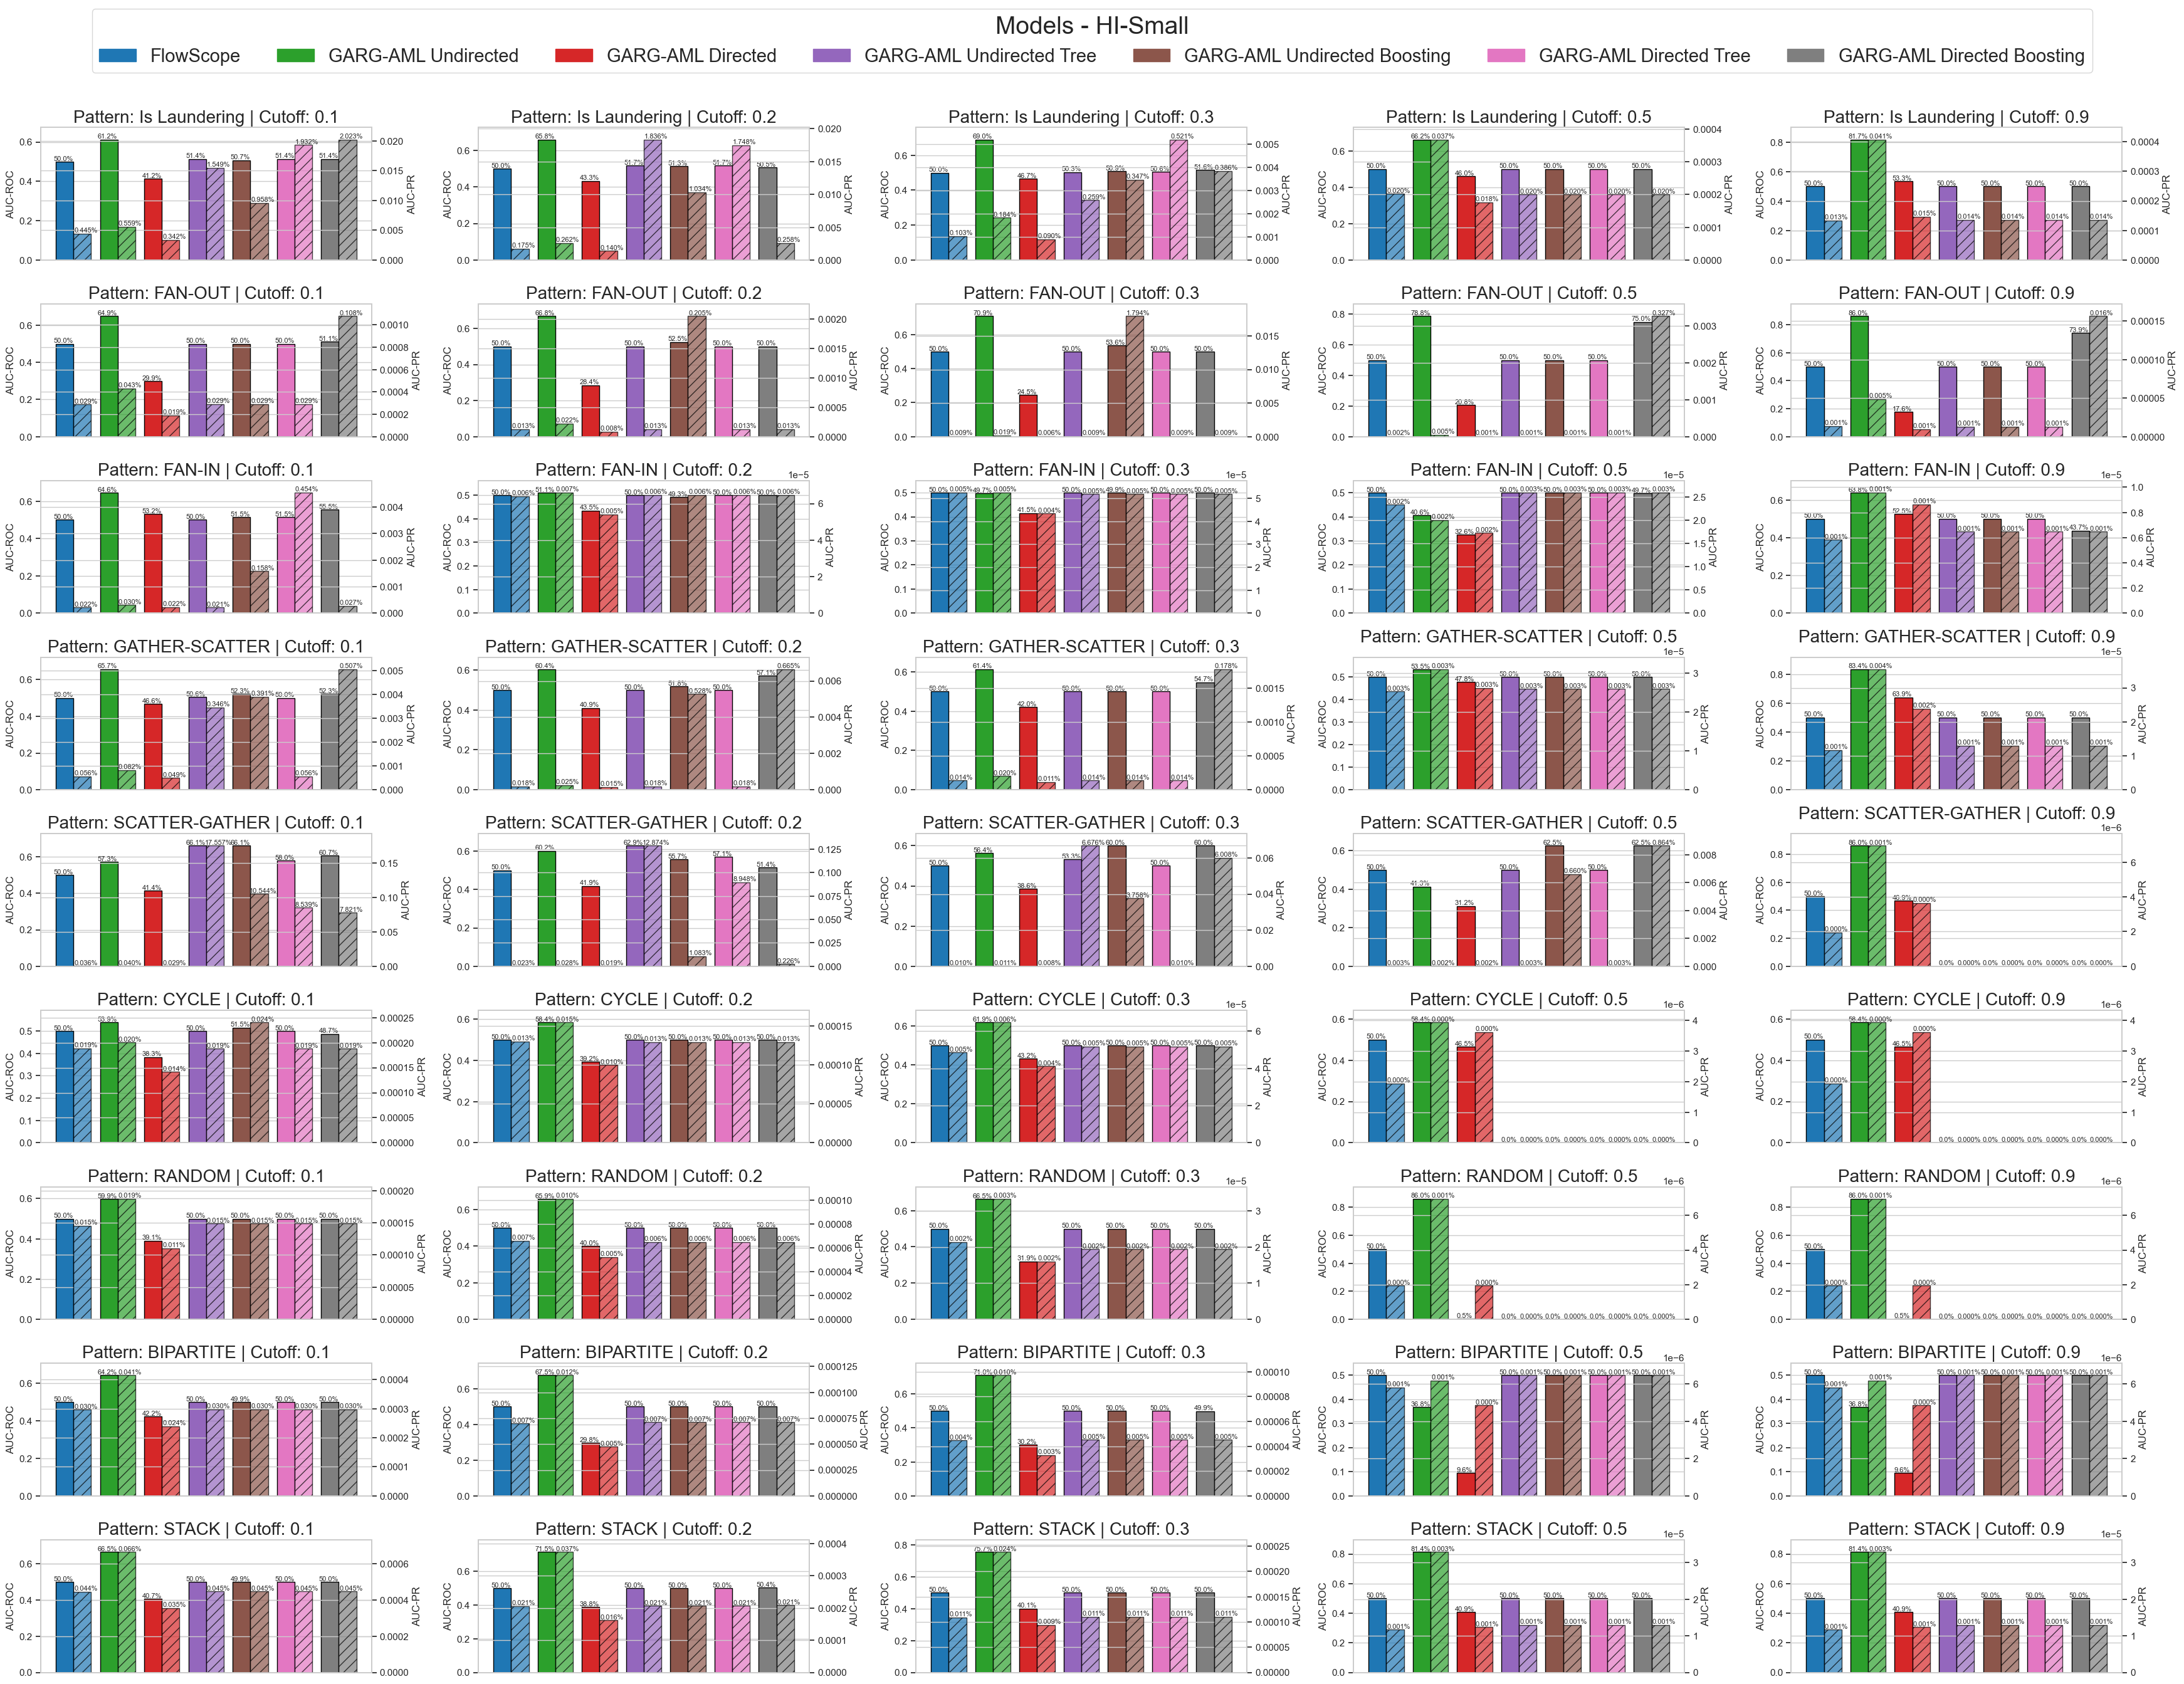

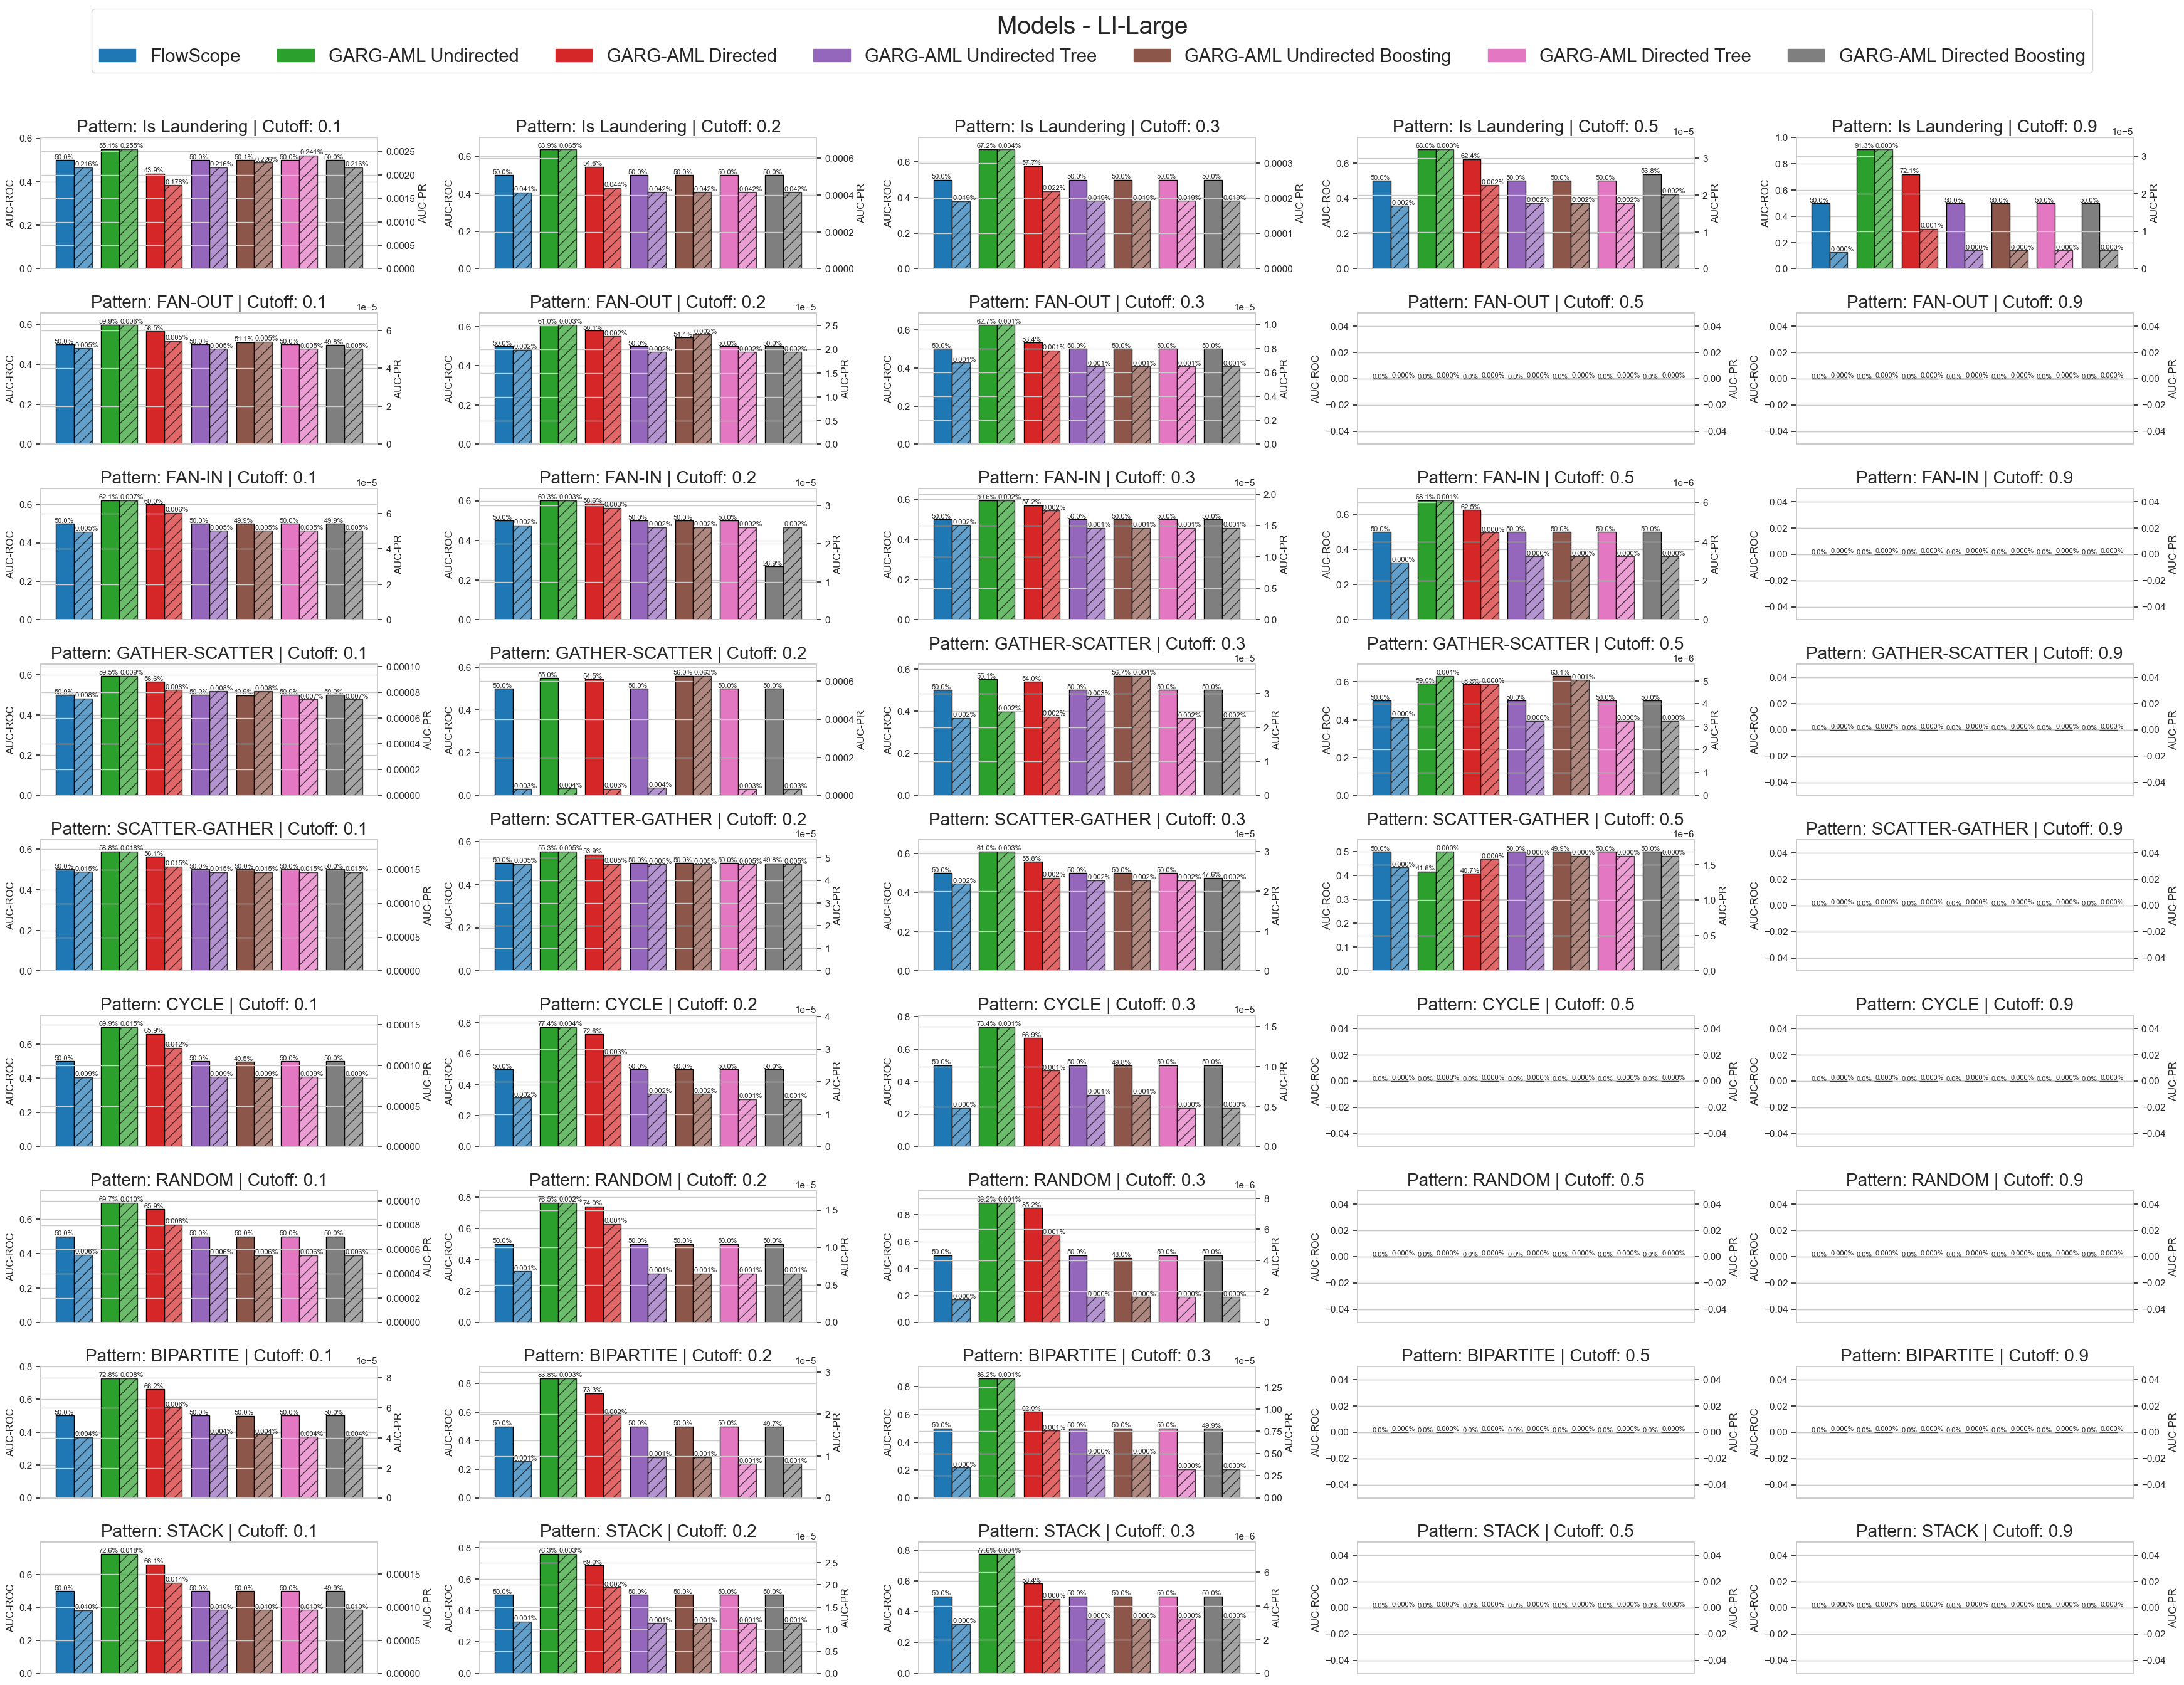

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = ['HI-Small', 'LI-Large']
for dataset in datasets:
    results_plot_df = results_df[(results_df['dataset']==dataset)]

    # Ensure consistent aesthetics
    sns.set(style="whitegrid")

    # Assume results_plot_df is already defined
    # Extract unique patterns and cutoffs
    patterns = results_plot_df['pattern'].unique()
    cutoffs = results_plot_df['cutoff'].unique()
    models = ['FlowScope','GARG-AML Undirected', 'GARG-AML Directed',
       'GARG-AML Undirected Tree', 'GARG-AML Undirected Boosting',
       'GARG-AML Directed Tree', 'GARG-AML Directed Boosting']
    palette = sns.color_palette("tab10", len(models)+1)
    del (palette[1])

    # Create a mapping from model names to colors
    model_color_map = dict(zip(models, palette))

    # Create the subplot grid
    fig, axes = plt.subplots(len(patterns), len(cutoffs), figsize=(7 * len(cutoffs), 3 * len(patterns)), squeeze=False)

    for i, pattern in enumerate(patterns):
        for j, cutoff in enumerate(cutoffs):
            ax = axes[i, j]
            subset = results_plot_df[(results_plot_df['pattern'] == pattern) & (results_plot_df['cutoff'] == cutoff)]
            ylim_max = subset['AUC-ROC'].max()*1.1
            ax.set_ylim(0, ylim_max)
            # Primary bar plot for AUC-ROC
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                roc = model_data['AUC-ROC'].values[0]
                ax.bar(idx - 0.2, model_data['AUC-ROC'], width=0.4, label=model if i == 0 and j == 0 else "", 
                    color=model_color_map[model], edgecolor='black')
                ax.text(idx - 0.23, roc-0.001, f"{roc*100:.1f}%", ha='center', va='bottom', fontsize=8)
            
            # Twin axis for AUC-PR
            ylim_max_2 = subset['AUC-PR'].max()*1.1
            ax2 = ax.twinx()
            ax2.set_ylim(0, ylim_max_2)
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                pr = model_data['AUC-PR'].values[0]
                ax2.bar(idx + 0.2, model_data['AUC-PR'], width=0.4, label=None, 
                        color=model_color_map[model], hatch='//', alpha=0.7, edgecolor='black')
                ax2.text(idx + 0.28, pr, f"{pr*100:.3f}%", ha='center', va='bottom', fontsize=8)

            ax.set_title(f"Pattern: {pattern} | Cutoff: {cutoff}", fontsize=20)
            ax.set_xticks([])
            ax.set_xticklabels([])
            #ax.set_xticks(range(len(models)))
            #ax.set_xticklabels(models, rotation=45, ha='right')
            ax.set_ylabel("AUC-ROC")
            ax2.set_ylabel("AUC-PR")

    # Add legend only once
    handles = [plt.Rectangle((0,0),1,1, color=model_color_map[m]) for m in models]
    fig.legend(handles, models, loc='upper center', ncol=len(models), title='Models - '+dataset, fontsize=21, title_fontsize=28)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig('../results/'+dataset+'_AUC-ROC_AUC-PR_full.pdf')